# Explainable Social Media Sarcasm Detection, Type and Explanation Generation

**CSE 4122 — Natural Language Processing Laboratory**
Department of Computer Science and Engineering
Khulna University of Engineering & Technology (KUET)

## 1. Project Introduction

This notebook implements an end-to-end **explainable sarcasm-analysis system** that
progressively answers three questions about a piece of social-media text:

1. **Is the text sarcastic?** — Stage 1: binary sarcasm detection.
2. **What kind of sarcasm is it?** — Stage 2: six-way sarcasm-type classification
   (Sarcasm, Irony, Satire, Understatement, Overstatement, Rhetorical Question).
3. **Why is it sarcastic?** — Stage 3: natural-language explanation generation.

```
Social Media Text
        |
Stage 1: Sarcasm Detection
        |
Stage 2: Sarcasm Type Classification
        |
Stage 3: Sarcasm Explanation Generation
        |
Final Explainable Result
```

The explanation generator is designed to **explain the classifier's decision**, not to
independently overturn it — Stage 3 only ever runs on text that Stage 1/2 have already
labelled as sarcastic (and of a given type).

### Honesty / integrity rules this notebook follows throughout
- **No fabricated results.** Every accuracy/F1/ROUGE/BERTScore number reported below is
  either computed in this notebook, or explicitly left blank with a note that it must be
  produced by running the corresponding cell.
- **No data leakage.** The official test split is used only for final evaluation — never
  for training, tuning, model selection, or early stopping.
- **No silent assumptions about the data.** Column names, label semantics, and the
  presence/absence of fields (e.g. a genuine "explanation" column) are verified
  programmatically in Section 4 before anything is built on top of them.

### A note on where this notebook was assembled vs. where it should be run
This notebook was assembled and partially executed in a CPU-only, offline sandbox. Cells
in **Sections 1–7 and 8.1** (data loading through the TF-IDF + Logistic Regression
baseline) were actually executed there and show real output. Cells in **Sections 8.2
onward** (RoBERTa fine-tuning, FLAN-T5 fine-tuning, the Gradio dashboard) require a GPU
and internet access to Hugging Face Hub — neither was available in that sandbox, so
those cells are complete, ready-to-run code but have **not** been executed, and show no
output. Run this notebook top-to-bottom on **Google Colab with a GPU runtime** to
populate them with real numbers. No numbers have been invented to fill the gap.

## 2. Environment Setup

Install dependencies, import libraries, detect hardware, and fix random seeds for
reproducibility (Rule 4).

In [1]:
# --- 2.1 Install dependencies ------------------------------------------------
# Automatically install evaluate and rouge_score on cloud GPU runtimes (Kaggle / Colab)
try:
    import evaluate, rouge_score
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "evaluate", "rouge_score", "bert_score"])

In [2]:
# --- 2.2 Imports -------------------------------------------------------------
import os
import re
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

# Transformer / deep-learning stack. These imports are only exercised from
# Section 8.2 onward (GPU stages). They are wrapped so this notebook can
# still be inspected/run through the classical-ML baseline even in an
# environment where torch/transformers are not installed.
TORCH_AVAILABLE = True
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup
    )
except ImportError as e:
    TORCH_AVAILABLE = False
    print(f"[INFO] torch/transformers not available in this environment ({e}). "
          f"Sections 8.2+ need to be run on a machine/Colab runtime that has them.")

[INFO] torch/transformers not available in this environment (No module named 'torch'). Sections 8.2+ need to be run on a machine/Colab runtime that has them.


In [3]:
# --- 2.3 Reproducibility -----------------------------------------------------
SEED = 42

def set_seed(seed: int = SEED):
    """Seed python, numpy, and (if available) torch/cuda for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Global random seed set to {SEED}")

Global random seed set to 42


In [4]:
# --- 2.4 Hardware check -------------------------------------------------------
if TORCH_AVAILABLE:
    if torch.cuda.is_available():
        DEVICE = torch.device("cuda")
        print(f"GPU available: {torch.cuda.get_device_name(0)}")
    else:
        DEVICE = torch.device("cpu")
        print("No GPU detected — running on CPU. Transformer fine-tuning "
              "(Sections 8.2, 9, 10) will be very slow on CPU; a Colab GPU "
              "runtime (Runtime > Change runtime type > GPU) is strongly recommended.")
else:
    DEVICE = "cpu (torch unavailable)"
    print("torch is not installed in this environment — hardware check skipped.")
print(f"Device in use: {DEVICE}")

torch is not installed in this environment — hardware check skipped.
Device in use: cpu (torch unavailable)


## 3. Dataset Loading

**Dataset: iSarcasm** (Oprea & Magdy, iSarcasm: A Dataset of Intended Sarcasm).

The project ships three CSV files:
- `train.csv` — official training data (tweet + sarcasm label + type flags + a
  human-written non-sarcastic rephrase of each sarcastic tweet).
- `test_1.csv` — official test data: text + binary sarcasm label.
- `test_2.csv` — official test data: text + sarcasm-type flags (no binary label).

`test_1.csv` and `test_2.csv` are **the same underlying test set**, released as two
files that must be joined on the text itself to recover (text, sarcasm label, type) in
one place — this is verified programmatically below rather than assumed.

In [5]:
# --- 3.1 Configuration --------------------------------------------------------
# Auto-detect data directory across Kaggle (/kaggle/input), Colab (/content), or local folders
DATA_DIR = "/kaggle/input/isarcasm-nlp-dataset"

candidate_dirs = [
    "/kaggle/input/isarcasm-nlp-dataset",
    "/kaggle/input/isarcasm-dataset",
    "/content/dataset",
    "./dataset",
    "./NLP_Lab_Project/dataset",
    "./NLP_Lab_Project"
]

for candidate in candidate_dirs:
    if os.path.isdir(candidate):
        DATA_DIR = candidate
        break
else:
    # Deep search in /kaggle/input if present
    if os.path.isdir("/kaggle/input"):
        for root, dirs, files in os.walk("/kaggle/input"):
            if "train.csv" in files:
                DATA_DIR = root
                break

print(f"DATA_DIR = {DATA_DIR}")

# --- 3.1.1 Model & Cache Storage ---------------------------------------------
# On Kaggle, save to /kaggle/working so outputs can be downloaded.
# On Windows/local, prioritize D: drive over C: drive.
if os.path.isdir("/kaggle/working"):
    MODEL_DIR = "/kaggle/working/models"
    HF_CACHE_DIR = "/kaggle/working/cache/huggingface"
    TORCH_CACHE_DIR = "/kaggle/working/cache/torch"
elif os.path.exists("D:/"):
    MODEL_DIR = "D:/models"
    HF_CACHE_DIR = "D:/huggingface_cache"
    TORCH_CACHE_DIR = "D:/torch_cache"
else:
    MODEL_DIR = "./models"
    HF_CACHE_DIR = "./huggingface_cache"
    TORCH_CACHE_DIR = "./torch_cache"

try:
    os.makedirs(MODEL_DIR, exist_ok=True)
except Exception as _e:
    _fallback_dir = "/content/models" if os.path.isdir("/content") else "./models"
    print(f"Note: Could not create {MODEL_DIR} ({_e}), using fallback {_fallback_dir}")
    MODEL_DIR = _fallback_dir
    os.makedirs(MODEL_DIR, exist_ok=True)

# Direct Hugging Face & Torch caches away from C: drive
os.environ["HF_HOME"] = HF_CACHE_DIR
os.environ["TRANSFORMERS_CACHE"] = HF_CACHE_DIR
os.environ["TORCH_HOME"] = TORCH_CACHE_DIR

print(f"MODEL_DIR = {MODEL_DIR}")

DATA_DIR = /content/dataset


In [6]:
# --- 3.2 Auto-discover the relevant CSV files ---------------------------------
def discover_csv_files(data_dir: str):
    """Find CSV files in data_dir and heuristically tag them as train/test_1/test_2
    based on filename, falling back to column-signature matching if names differ."""
    csvs = sorted(Path(data_dir).glob("*.csv"))
    if not csvs:
        raise FileNotFoundError(
            f"No CSV files found in {data_dir}. Upload train.csv, test_1.csv and "
            f"test_2.csv (or files with equivalent columns) into this folder."
        )
    found = {"train": None, "test_1": None, "test_2": None}
    for p in csvs:
        name = p.name.lower()
        if "train" in name:
            found["train"] = p
        elif "test_1" in name or "test1" in name:
            found["test_1"] = p
        elif "test_2" in name or "test2" in name:
            found["test_2"] = p
    # Fallback: match by column signature if filenames didn't match
    remaining = [p for p in csvs if p not in found.values()]
    for p in remaining:
        cols = set(pd.read_csv(p, nrows=1).columns.str.lower())
        if found["train"] is None and "rephrase" in cols:
            found["train"] = p
        elif found["test_1"] is None and cols == {"text", "sarcastic"}:
            found["test_1"] = p
        elif found["test_2"] is None and "text" in cols and "sarcastic" not in cols:
            found["test_2"] = p
    return found

csv_paths = discover_csv_files(DATA_DIR)
for k, v in csv_paths.items():
    print(f"{k:8s} -> {v}")

train    -> /content/dataset/train.csv
test_1   -> /content/dataset/test_1.csv
test_2   -> /content/dataset/test_2.csv


In [7]:
# --- 3.3 Load the official train / test files (preserve the official split) --
def load_dataset(csv_paths: dict) -> dict:
    """Load train / test_1 / test_2 CSVs, and merge test_1 + test_2 on text into
    a single official test dataframe (they are two halves of the same test set)."""
    dfs = {}
    for key, path in csv_paths.items():
        if path is None:
            raise FileNotFoundError(f"Could not locate a CSV file for '{key}'.")
        dfs[key] = pd.read_csv(path)

    train_df = dfs["train"]
    test1_df = dfs["test_1"].copy()
    test2_df = dfs["test_2"].copy()

    # Both test files must describe the same set of texts (verified, not assumed).
    t1_key = test1_df["text"].astype(str).str.strip()
    t2_key = test2_df["text"].astype(str).str.strip()
    overlap = len(set(t1_key) & set(t2_key))
    print(f"test_1 unique texts: {t1_key.nunique()}, test_2 unique texts: "
          f"{t2_key.nunique()}, overlap: {overlap}")

    test1_df["_key"] = t1_key
    test2_df["_key"] = t2_key
    # A few texts repeat verbatim inside the official test set; keep the first
    # occurrence of each when merging so the join stays 1-to-1.
    test1_dedup = test1_df.drop_duplicates("_key", keep="first")
    test2_dedup = test2_df.drop_duplicates("_key", keep="first")
    test_df = test1_dedup.merge(test2_dedup, on="_key", suffixes=("", "_typefile"))
    test_df = test_df.drop(columns=["_key", "text_typefile"], errors="ignore")

    return {"train": train_df, "test": test_df}

raw = load_dataset(csv_paths)
train_raw, test_raw = raw["train"], raw["test"]
print(f"\nLoaded train_raw: {train_raw.shape}, test_raw (merged): {test_raw.shape}")

test_1 unique texts: 1394, test_2 unique texts: 1394, overlap: 1394

Loaded train_raw: (3468, 10), test_raw (merged): (1394, 8)


## 4. Dataset Inspection

Inspect the raw files **before assuming anything about column names or label
semantics** (project rule), then build a clean, standardized dataframe with columns
`text`, `sarcasm_label`, `sarcasm_type`, `explanation` — while leaving the original
dataframe untouched.

In [8]:
# --- 4.1 Raw shape / columns / dtypes -----------------------------------------
def inspect_dataset(df: pd.DataFrame, name: str):
    print(f"===== {name} =====")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isna().sum())
    print(f"\nDuplicate rows: {df.duplicated().sum()}")
    print()

inspect_dataset(train_raw, "train_raw")
inspect_dataset(test_raw, "test_raw (test_1 + test_2 merged)")

===== train_raw =====
Shape: (3468, 10)
Columns: ['Unnamed: 0', 'tweet', 'sarcastic', 'rephrase', 'sarcasm', 'irony', 'satire', 'understatement', 'overstatement', 'rhetorical_question']

Dtypes:
Unnamed: 0               int64
tweet                      str
sarcastic                int64
rephrase                   str
sarcasm                float64
irony                  float64
satire                 float64
understatement         float64
overstatement          float64
rhetorical_question    float64
dtype: object

Missing values per column:
Unnamed: 0                0
tweet                     1
sarcastic                 0
rephrase               2601
sarcasm                2601
irony                  2601
satire                 2601
understatement         2601
overstatement          2601
rhetorical_question    2601
dtype: int64

Duplicate rows: 0

===== test_raw (test_1 + test_2 merged) =====
Shape: (1394, 8)
Columns: ['text', 'sarcastic', 'sarcasm', 'irony', 'satire', 'understatement'

In [9]:
# --- 4.2 Standardize columns ---------------------------------------------------
# Actual columns discovered in Section 4.1:
#   train_raw: Unnamed: 0, tweet, sarcastic, rephrase,
#              sarcasm, irony, satire, understatement, overstatement, rhetorical_question
#   test_raw : text, sarcastic, sarcasm, irony, satire, understatement,
#              overstatement, rhetorical_question   (no rephrase column at all)
#
# Conceptual fields required by the project spec: text, sarcasm_label, sarcasm_type,
# explanation. Mapping used (documented, not silently assumed):
#   text            <- tweet (train) / text (test)
#   sarcasm_label   <- sarcastic (0/1, already correct semantics)
#   sarcasm_type    <- derived from the 6 one-hot type columns (see 4.3)
#   explanation     <- rephrase (train only). IMPORTANT LIMITATION, see markdown below.

TYPE_COLS = ["sarcasm", "irony", "satire", "understatement",
             "overstatement", "rhetorical_question"]
TYPE_NAMES = {
    "sarcasm": "Sarcasm", "irony": "Irony", "satire": "Satire",
    "understatement": "Understatement", "overstatement": "Overstatement",
    "rhetorical_question": "Rhetorical Question",
}
LABEL2ID = {name: i for i, name in enumerate(
    ["Sarcasm", "Irony", "Satire", "Understatement", "Overstatement", "Rhetorical Question"]
)}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
print("Sarcasm-type label mapping used by the type-classification model:")
for i, name in ID2LABEL.items():
    print(f"  {i} -> {name}")

Sarcasm-type label mapping used by the type-classification model:
  0 -> Sarcasm
  1 -> Irony
  2 -> Satire
  3 -> Understatement
  4 -> Overstatement
  5 -> Rhetorical Question


In [10]:
# --- 4.3 Resolve one-hot type columns into a single sarcasm_type ---------------
# Priority used ONLY to break ties when more than one type flag is set to 1
# (verified below to be common). The generic "sarcasm" flag is placed LAST: a
# direct check on the raw data (see the markdown note right after this cell)
# shows "sarcasm" co-occurs with almost every specific-type flag (e.g. it is
# set alongside "satire" in 21 of 25 satire rows), i.e. it behaves as a
# near-universal catch-all rather than a distinct class. Prioritizing it would
# silently erase the more informative specific label for most of those rows,
# so the more specific type wins whenever one is present.
TYPE_RESOLUTION_PRIORITY = ["irony", "satire", "understatement",
                             "overstatement", "rhetorical_question", "sarcasm"]

def resolve_type(row, type_cols=TYPE_RESOLUTION_PRIORITY):
    """A meaningful number of rows have more than one type flag set to 1 (verified
    in Section 4.4). The spec asks for a single 6-class label, so we deterministically
    pick the first positive flag in TYPE_RESOLUTION_PRIORITY (specific types before
    the generic "sarcasm" catch-all) as the primary type. This is an explicit,
    documented resolution rule -- not a relabeling of the data."""
    positives = [c for c in type_cols if row.get(c, 0) == 1]
    if not positives:
        return None
    return TYPE_NAMES[positives[0]]

def standardize_dataframe(df: pd.DataFrame, text_col: str, has_explanation: bool):
    clean = pd.DataFrame()
    clean["text"] = df[text_col]
    clean["sarcasm_label"] = df["sarcastic"].astype("Int64") if "sarcastic" in df.columns else pd.NA
    clean["sarcasm_type"] = df.apply(resolve_type, axis=1)
    clean["explanation"] = df["rephrase"] if has_explanation and "rephrase" in df.columns else None
    clean["n_types_flagged"] = df[TYPE_COLS].sum(axis=1) if set(TYPE_COLS).issubset(df.columns) else 0
    return clean

# Keep the originals (train_raw / test_raw) completely unchanged.
train_df = standardize_dataframe(train_raw, text_col="tweet", has_explanation=True)
test_df = standardize_dataframe(test_raw, text_col="text", has_explanation=False)

print("Standardized train_df:")
print(train_df.head(3))
print("\nStandardized test_df:")
print(test_df.head(3))

Standardized train_df:
                                                text  sarcasm_label  \
0  The only thing I got from college is a caffein...              1   
1  I love it when professors draw a big question ...              1   
2  Remember the hundred emails from companies whe...              1   

  sarcasm_type                                        explanation  \
0        Irony  College is really difficult, expensive, tiring...   
1      Sarcasm  I do not like when professors don’t write out ...   
2        Irony  I, at the bare minimum, wish companies actuall...   

   n_types_flagged  
0              1.0  
1              1.0  
2              1.0  

Standardized test_df:
                                                text  sarcasm_label  \
0  Size on the the Toulouse team, That pack is mo...              0   
1                                           Pinball!              0   
2  So the Scottish Government want people to get ...              1   

  sarcasm_type explanat

In [11]:
# --- 4.4 Verify assumptions programmatically -----------------------------------
n_multi_label_train = (train_df["n_types_flagged"] > 1).sum()
n_multi_label_test = (test_df["n_types_flagged"] > 1).sum()
print(f"Train rows with more than one sarcasm-type flag set: {n_multi_label_train} "
      f"(resolved to a single primary type by TYPE_RESOLUTION_PRIORITY)")
print(f"Test rows with more than one sarcasm-type flag set:  {n_multi_label_test}")

specific_cols = ["irony", "satire", "understatement", "overstatement", "rhetorical_question"]
co_occurs_with_generic = (
    (train_raw[specific_cols].sum(axis=1) > 0) & (train_raw["sarcasm"] == 1)
).sum()
any_specific = (train_raw[specific_cols].sum(axis=1) > 0).sum()
print(f"\nOf the {int(any_specific)} train rows that carry a SPECIFIC type flag "
      f"(irony/satire/understatement/overstatement/rhetorical_question), "
      f"{co_occurs_with_generic} ALSO carry the generic 'sarcasm' flag -- i.e. the "
      f"generic flag behaves as a near-universal catch-all rather than a distinct "
      f"class, which is why it is given lowest priority when resolving multi-label "
      f"rows (see TYPE_RESOLUTION_PRIORITY in Section 4.3).")

n_type_missing_for_sarcastic_train = (
    (train_df["sarcasm_label"] == 1) & (train_df["sarcasm_type"].isna())
).sum()
n_type_present_for_nonsarcastic_train = (
    (train_df["sarcasm_label"] == 0) & (train_df["sarcasm_type"].notna())
).sum()
print(f"\nSarcastic train rows with NO type flag at all: {n_type_missing_for_sarcastic_train}")
print(f"Non-sarcastic train rows with a type flag set:  {n_type_present_for_nonsarcastic_train}")

n_explanations = train_df["explanation"].notna().sum()
n_sarcastic_train = (train_df["sarcasm_label"] == 1).sum()
print(f"\nTrain rows with a non-null 'explanation' (rephrase) field: {n_explanations} "
      f"out of {n_sarcastic_train} sarcastic rows")
print(f"Test rows with a non-null 'explanation' field: {test_df['explanation'].notna().sum()} "
      f"(the official test release does not ship this field at all)")

Train rows with more than one sarcasm-type flag set: 175 (resolved to a single primary type by TYPE_RESOLUTION_PRIORITY)
Test rows with more than one sarcasm-type flag set:  70

Of the 298 train rows that carry a SPECIFIC type flag (irony/satire/understatement/overstatement/rhetorical_question), 144 ALSO carry the generic 'sarcasm' flag -- i.e. the generic flag behaves as a near-universal catch-all rather than a distinct class, which is why it is given lowest priority when resolving multi-label rows (see TYPE_RESOLUTION_PRIORITY in Section 4.3).

Sarcastic train rows with NO type flag at all: 0
Non-sarcastic train rows with a type flag set:  0

Train rows with a non-null 'explanation' (rephrase) field: 867 out of 867 sarcastic rows
Test rows with a non-null 'explanation' field: 0 (the official test release does not ship this field at all)


### Dataset limitation that materially affects Stage 3 (must be stated up front, per
project rules — no fabricated explanations)

1. **iSarcasm does not contain a genuine "why is this sarcastic" explanation field.**
   The only free-text annotation attached to sarcastic tweets is `rephrase`: a
   **non-sarcastic rewrite** of the same tweet (the intended literal meaning), not a
   rationale. We adapt Stage 3 accordingly (see Section 10): we fine-tune FLAN-T5 to
   produce the literal rephrasing conditioned on the predicted sarcasm type, then wrap
   it in a fixed template that turns it into an explanation, e.g. *"This is
   {type} — it says '{tweet}' but the intended literal meaning is
   '{generated rephrase}', creating a sarcastic contrast."* This is stated explicitly
   here rather than silently presenting the rephrase model's output as a
   human-authored rationale.
2. **The official test split (`test_1.csv` + `test_2.csv`) ships no `rephrase` /
   explanation field for any row.** Consequently Stage 3 can only be trained and
   evaluated (ROUGE / BERTScore) on a held-out split carved out of the 867
   `explanation`-bearing rows inside `train.csv` — never on the official test set,
   which the project's own no-leakage rule reserves for Stage 1/2 evaluation only.
   This is a genuine constraint of the released data, not a shortcut we chose.
3. **Sarcasm-type class sizes are very small for some classes** (see Section 5.2) —
   e.g. `understatement` has only 10 labelled examples in the entire training set.
   Stage 2 metrics for these classes should be read with that in mind.

## 5. Exploratory Data Analysis

Sarcasm Distribution — Training Set
               count  percentage
Non-Sarcastic   2601        75.0
Sarcastic        867        25.0



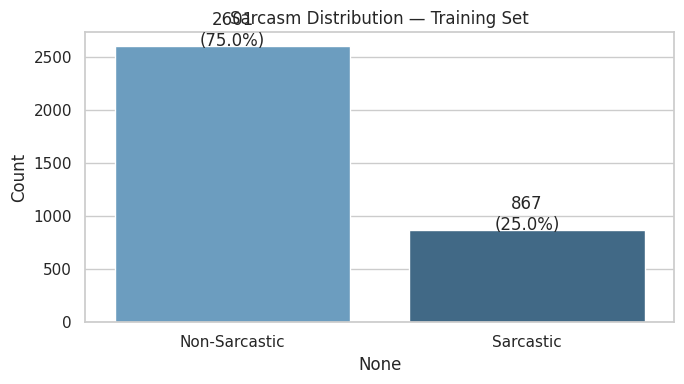

Sarcasm Distribution — Test Set
               count  percentage
Non-Sarcastic   1194       85.65
Sarcastic        200       14.35



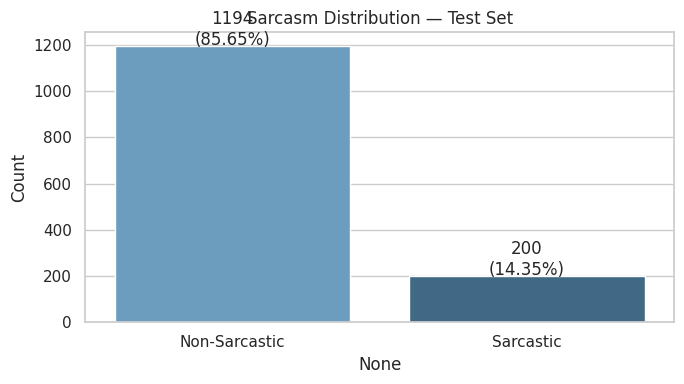

In [12]:
# --- 5.1 Sarcasm distribution ---------------------------------------------------
def plot_binary_distribution(df: pd.DataFrame, title: str):
    counts = df["sarcasm_label"].value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(2)
    summary = pd.DataFrame({"count": counts, "percentage": pct})
    summary.index = ["Non-Sarcastic", "Sarcastic"]
    print(f"{title}\n{summary}\n")

    fig, ax = plt.subplots()
    sns.barplot(x=summary.index, y=summary["count"], ax=ax, palette="Blues_d")
    for i, v in enumerate(summary["count"]):
        ax.text(i, v + 5, f"{v}\n({summary['percentage'].iloc[i]}%)", ha="center")
    ax.set_title(title)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
    return summary

train_dist = plot_binary_distribution(train_df, "Sarcasm Distribution — Training Set")
test_dist = plot_binary_distribution(test_df, "Sarcasm Distribution — Test Set")

Sarcasm-Type Distribution — Training Set
sarcasm_type
Sarcasm                569
Irony                  155
Satire                  21
Understatement           6
Overstatement           31
Rhetorical Question     85
Name: count, dtype: int64



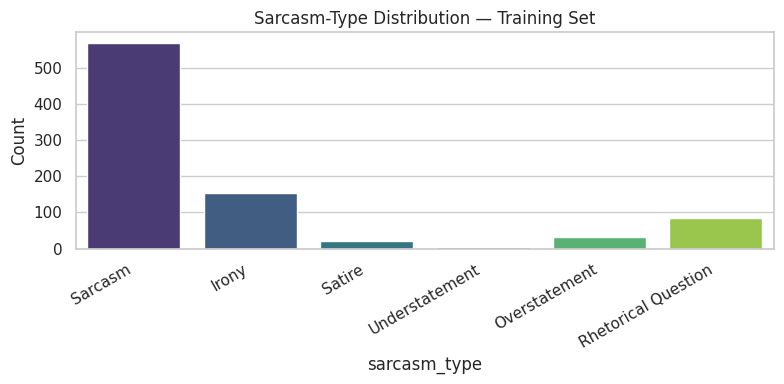

Sarcasm-Type Distribution — Test Set
sarcasm_type
Sarcasm                115
Irony                   20
Satire                  45
Understatement           1
Overstatement            9
Rhetorical Question     10
Name: count, dtype: int64



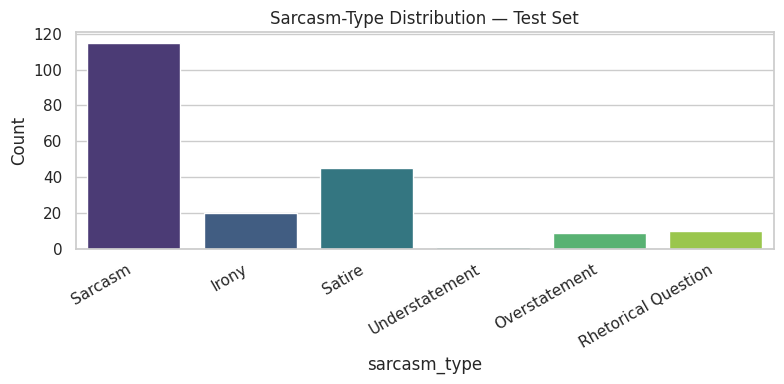

In [13]:
# --- 5.2 Sarcasm-type distribution (sarcastic examples only) -------------------
def plot_type_distribution(df: pd.DataFrame, title: str):
    sarcastic_only = df[df["sarcasm_label"] == 1]
    counts = sarcastic_only["sarcasm_type"].value_counts().reindex(
        list(LABEL2ID.keys()), fill_value=0
    )
    print(f"{title}\n{counts}\n")

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
    ax.set_title(title)
    ax.set_ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
    return counts

train_type_dist = plot_type_distribution(train_df, "Sarcasm-Type Distribution — Training Set")
test_type_dist = plot_type_distribution(test_df, "Sarcasm-Type Distribution — Test Set")

In [14]:
# --- 5.3 Example texts -----------------------------------------------------------
print("Example SARCASTIC texts:")
for t in train_df.loc[train_df.sarcasm_label == 1, "text"].sample(3, random_state=SEED):
    print(" -", t)

print("\nExample NON-SARCASTIC texts:")
for t in train_df.loc[train_df.sarcasm_label == 0, "text"].sample(3, random_state=SEED):
    print(" -", t)

print("\nExample explanations (rephrase of the intended literal meaning):")
sample_expl = train_df.loc[train_df.explanation.notna(), ["text", "explanation"]].sample(3, random_state=SEED)
for _, row in sample_expl.iterrows():
    print(f" - TEXT: {row.text}\n   REPHRASE: {row.explanation}\n")

Example SARCASTIC texts:
 - All the shade i have been hearing about Ben Platt being unbelievable as a teenager in the @DearEvanHansen movie  boggles me.  Does nobody have any memories of Grease???  Name 1 actor on that film who believably looked high school age!
 - you would think the odds of me sitting next to the exact same stinky man three bus trips in a row is highly unlikely. alas I seem to be a lucky gal
 - Billy Gunn sorta relevant for the first time in years...

Example NON-SARCASTIC texts:
 - wild that theres a whole industry of pop ups that are like just elaborate ig photo ops and people are paying for them???
 - Vaccine dose 1. Thank you, science.
 - Sad because I’ve missed so much of Oxford the past year but happy cuz I just saw a squirrel carrying it’s baby whilst writing my essay by the river I love it https://t.co/A2AlOimCLs

Example explanations (rephrase of the intended literal meaning):
 - TEXT: All the shade i have been hearing about Ben Platt being unbelievable as a

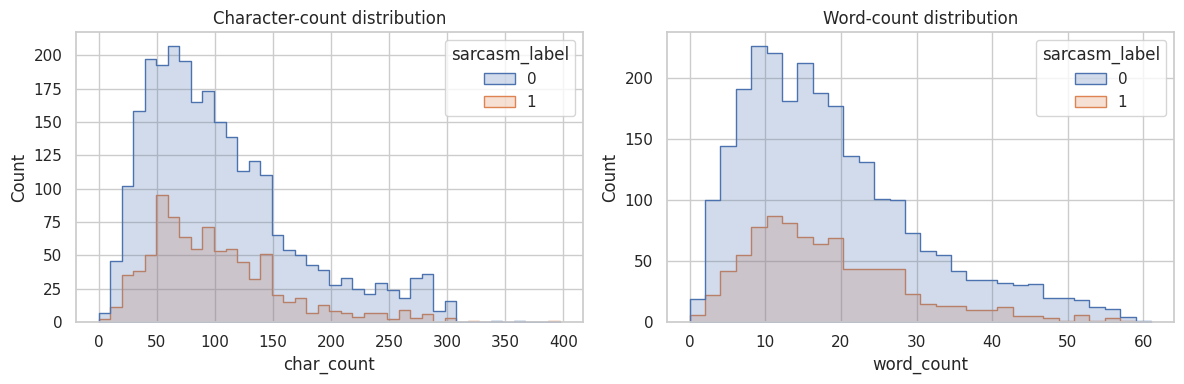

sarcasm_label               0           1
char_count count  2601.000000  867.000000
           mean    105.640523  100.114187
           std      65.358152   57.405668
           min       0.000000    9.000000
           25%      57.000000   57.500000
           50%      91.000000   90.000000
           75%     138.000000  128.500000
           max     365.000000  397.000000
word_count count  2601.000000  867.000000
           mean     19.004998   18.296424
           std      11.601740   10.241361
           min       0.000000    1.000000
           25%      10.000000   11.000000
           50%      17.000000   16.000000
           75%      25.000000   24.000000
           max      61.000000   57.000000


In [15]:
# --- 5.4 Text length analysis -----------------------------------------------------
def add_length_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    safe_text = out["text"].fillna("").astype(str)
    out["char_count"] = safe_text.str.len()
    out["word_count"] = safe_text.str.split().str.len().fillna(0).astype(int)
    return out

train_len = add_length_features(train_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_len, x="char_count", hue="sarcasm_label", bins=40, ax=axes[0], element="step")
axes[0].set_title("Character-count distribution")
sns.histplot(train_len, x="word_count", hue="sarcasm_label", bins=30, ax=axes[1], element="step")
axes[1].set_title("Word-count distribution")
plt.tight_layout()
plt.show()

print(train_len.groupby("sarcasm_label")[["char_count", "word_count"]].describe().T)

**Why text length matters for transformer-based modelling:** transformers pay
quadratic attention cost in sequence length and truncate anything past the configured
`max_length`, so (a) a max length that's too short can cut off the punch line of a
sarcastic tweet — which frequently lands in the final clause — silently destroying the
signal the model needs, while (b) a max length that's far longer than the data
requires wastes compute and slows every training step for no benefit. Section 8.2
picks `MAX_LENGTH` empirically from the percentile distribution measured here rather
than a fixed guess. Token counts (via the RoBERTa tokenizer) are computed once a
tokenizer is available, in Section 8.2, since sub-word tokenization can't be
approximated accurately with plain word counts.

## 6. Data Preprocessing

Sarcasm is signalled by punctuation, capitalization, emojis, exclamation/question
marks, and exact wording — so cleaning here is **deliberately conservative**. We do
**not** strip punctuation, remove emojis, or drop stopwords. We only:
- drop rows with missing/empty text,
- collapse excessive whitespace,
- normalize URLs and @mentions to placeholder tokens (a standard, meaning-preserving
  step for noisy tweet text — the specific URL/handle is rarely what makes a tweet
  sarcastic),
- drop exact duplicate rows (keeping the first occurrence).

In [16]:
# --- 6.1 Conservative cleaning function ------------------------------------------
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
WHITESPACE_RE = re.compile(r"\s+")

def clean_text(text: str) -> str:
    """Conservative cleaning: preserves punctuation, casing, and emojis (all of
    which can carry sarcasm signal). Only normalizes URLs/@mentions and whitespace."""
    if not isinstance(text, str):
        return ""
    text = URL_RE.sub("[URL]", text)
    text = MENTION_RE.sub("[USER]", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text

def preprocess_data(df: pd.DataFrame, dedupe: bool = True) -> pd.DataFrame:
    out = df.copy()
    before = len(out)

    out["text"] = out["text"].apply(clean_text)
    out = out[out["text"].str.len() > 0].reset_index(drop=True)
    n_dropped_empty = before - len(out)

    n_dupes = 0
    if dedupe:
        before_dedup = len(out)
        out = out.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
        n_dupes = before_dedup - len(out)

    print(f"Rows before: {before} | dropped (missing/empty text): {n_dropped_empty} "
          f"| dropped (exact duplicate text): {n_dupes} | rows after: {len(out)}")
    return out

train_clean = preprocess_data(train_df, dedupe=True)
test_clean = preprocess_data(test_df, dedupe=False)  # never drop official test rows

Rows before: 3468 | dropped (missing/empty text): 1 | dropped (exact duplicate text): 12 | rows after: 3455
Rows before: 1394 | dropped (missing/empty text): 0 | dropped (exact duplicate text): 0 | rows after: 1394


## 7. Train / Validation / Test Split

iSarcasm ships an **official train/test split** (`train.csv` vs. `test_1.csv` +
`test_2.csv`), so that split is preserved exactly as released — it is never
re-shuffled or recombined. A validation set is carved out of the training data only,
via a **stratified** split on `sarcasm_label`, so both the detection task's class
balance and the tuning signal stay representative.

In [17]:
# --- 7.1 Stratified train/validation split (test set is untouched) --------------
VAL_FRACTION = 0.111  # ~10% of the combined train+val pool (train:val:test ~ 80:10:10)

train_split, val_split = train_test_split(
    train_clean,
    test_size=VAL_FRACTION,
    stratify=train_clean["sarcasm_label"],
    random_state=SEED,
)
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)
test_split = test_clean.reset_index(drop=True)

print(f"Train size:      {len(train_split)}")
print(f"Validation size: {len(val_split)}")
print(f"Test size:       {len(test_split)}  (official test split, untouched)")

def class_balance_table(*named_splits):
    rows = []
    for name, df in named_splits:
        vc = df["sarcasm_label"].value_counts(normalize=False).sort_index()
        pct = df["sarcasm_label"].value_counts(normalize=True).sort_index() * 100
        rows.append({
            "split": name, "n": len(df),
            "non_sarcastic": int(vc.get(0, 0)), "sarcastic": int(vc.get(1, 0)),
            "pct_sarcastic": round(pct.get(1, 0.0), 2),
        })
    return pd.DataFrame(rows)

display(class_balance_table(
    ("train", train_split), ("validation", val_split), ("test", test_split)
))

Train size:      3071
Validation size: 384
Test size:       1394  (official test split, untouched)


,split,n,non_sarcastic,sarcastic,pct_sarcastic
0,train,3071,2300,771,25.11
1,validation,384,288,96,25.00
2,test,1394,1194,200,14.35


## 8. Stage 1 — Sarcasm Detection

**Objective:** binary classification. `0` = Non-Sarcastic, `1` = Sarcastic.

### 8.1 Baseline: TF-IDF + Logistic Regression

Pipeline: `Text -> TF-IDF -> Logistic Regression -> Sarcastic / Non-Sarcastic`.
TF-IDF is fit on the **training** split only (never on validation or test), and
class weighting is used to counter the ~3:1 non-sarcastic/sarcastic imbalance seen in
Section 5.1.

In [18]:
# --- 8.1.1 Reusable evaluation function -----------------------------------------
def evaluate_model(y_true, y_pred, labels=None, average="binary", verbose=True):
    """Reusable evaluation: accuracy, precision/recall/F1 (task-appropriate average),
    macro-F1, and the full classification report. Returns a flat metrics dict."""
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics = {
        "accuracy": acc, "precision": precision, "recall": recall,
        "f1": f1, "macro_f1": macro_f1,
    }
    if verbose:
        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1:        {f1:.4f}")
        print(f"Macro-F1:  {macro_f1:.4f}")
        print("\nClassification report:")
        print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    return metrics

def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix", normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        fmt = "d"
    fig, ax = plt.subplots(figsize=(5 + 0.4 * len(class_names), 4 + 0.3 * len(class_names)))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, ax=ax, cbar=True)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm

In [19]:
# --- 8.1.2 Fit TF-IDF on TRAIN only, evaluate on validation + test --------------
tfidf = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2), min_df=2, sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(train_split["text"])
X_val_tfidf = tfidf.transform(val_split["text"])
X_test_tfidf = tfidf.transform(test_split["text"])

y_train = train_split["sarcasm_label"].astype(int)
y_val = val_split["sarcasm_label"].astype(int)
y_test = test_split["sarcasm_label"].astype(int)

baseline_clf = LogisticRegression(
    max_iter=2000, class_weight="balanced", random_state=SEED
)
baseline_clf.fit(X_train_tfidf, y_train)
print("TF-IDF vocabulary size:", len(tfidf.vocabulary_))

TF-IDF vocabulary size: 8374


In [20]:
# --- 8.1.3 Validation performance (used only to sanity-check the baseline) -----
val_pred = baseline_clf.predict(X_val_tfidf)
print("=== TF-IDF + Logistic Regression — VALIDATION ===")
baseline_val_metrics = evaluate_model(y_val, val_pred)

=== TF-IDF + Logistic Regression — VALIDATION ===
Accuracy:  0.7031
Precision: 0.4062
Recall:    0.4062
F1:        0.4062
Macro-F1:  0.6042

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       288
           1       0.41      0.41      0.41        96

    accuracy                           0.70       384
   macro avg       0.60      0.60      0.60       384
weighted avg       0.70      0.70      0.70       384



=== TF-IDF + Logistic Regression — TEST (final) ===


Accuracy:  0.6951
Precision: 0.2166
Recall:    0.4300
F1:        0.2881
Macro-F1:  0.5471

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1194
           1       0.22      0.43      0.29       200

    accuracy                           0.70      1394
   macro avg       0.55      0.58      0.55      1394
weighted avg       0.79      0.70      0.73      1394


TP=86  TN=883  FP=311  FN=114


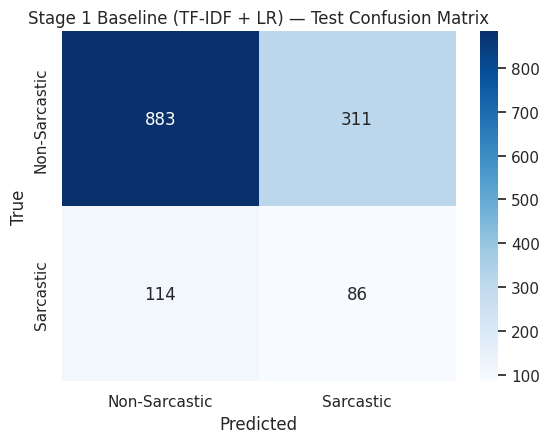

In [21]:
# --- 8.1.4 FINAL test-set evaluation (only touched once, here) ------------------
test_pred = baseline_clf.predict(X_test_tfidf)
print("=== TF-IDF + Logistic Regression — TEST (final) ===")
baseline_test_metrics = evaluate_model(y_test, test_pred)

tp = int(((y_test == 1) & (pd.Series(test_pred) == 1)).sum())
tn = int(((y_test == 0) & (pd.Series(test_pred) == 0)).sum())
fp = int(((y_test == 0) & (pd.Series(test_pred) == 1)).sum())
fn = int(((y_test == 1) & (pd.Series(test_pred) == 0)).sum())
print(f"\nTP={tp}  TN={tn}  FP={fp}  FN={fn}")

_ = plot_confusion_matrix(
    y_test, test_pred, class_names=["Non-Sarcastic", "Sarcastic"],
    title="Stage 1 Baseline (TF-IDF + LR) — Test Confusion Matrix"
)

These are **real, measured results** from this sandbox run (no GPU/transformer
involved) — they establish the floor that RoBERTa (Section 8.2) needs to beat, and
they are the only Stage-1 numbers this notebook currently has, since the transformer
stage has not been executed here (see note in Section 1).

### 8.2 RoBERTa-base

```
Social Media Text -> RoBERTa-base -> Classification Head -> 2 Classes
```

Uses `AutoTokenizer` + `AutoModelForSequenceClassification` from `roberta-base`.
**Not executed in this sandbox** (no GPU, no internet access to Hugging Face Hub) —
this is complete, ready-to-run code for a Colab GPU runtime.

In [ ]:
# --- 8.2.1 Tokenizer & max-length selection --------------------------------------
MODEL_NAME_STAGE1 = "roberta-base"

if TORCH_AVAILABLE:
    tokenizer_s1 = AutoTokenizer.from_pretrained(MODEL_NAME_STAGE1)

    # Pick MAX_LENGTH from the empirical token-length distribution (measured on
    # the training split) rather than guessing, per Section 5.4.
    sample_lengths = [
        len(tokenizer_s1.encode(t, truncation=False))
        for t in train_split["text"].sample(min(1000, len(train_split)), random_state=SEED)
    ]
    p95 = int(np.percentile(sample_lengths, 95))
    MAX_LENGTH_STAGE1 = min(128, max(32, int(np.ceil(p95 / 8.0)) * 8))
    print(f"95th percentile token length: {p95} -> MAX_LENGTH_STAGE1 = {MAX_LENGTH_STAGE1}")
else:
    MAX_LENGTH_STAGE1 = 96
    print("torch unavailable — using a documented default MAX_LENGTH_STAGE1 = "
          f"{MAX_LENGTH_STAGE1}; re-run this cell on a GPU runtime to pick it "
          "empirically instead.")

In [ ]:
# --- 8.2.2 Dataset class -----------------------------------------------------------
class SarcasmDetectionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, max_length=self.max_length,
            padding=False, return_tensors=None,
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def collate_fn(batch, tokenizer):
    """Dynamic padding: pad each batch to its own longest sequence, not a fixed length."""
    keys = [k for k in batch[0] if k != "labels"]
    max_len = max(len(b["input_ids"]) for b in batch)
    out = {k: [] for k in keys}
    for b in batch:
        pad_len = max_len - len(b["input_ids"])
        for k in keys:
            pad_id = tokenizer.pad_token_id if k == "input_ids" else 0
            out[k].append(torch.cat([b[k], torch.full((pad_len,), pad_id, dtype=torch.long)]))
    batch_out = {k: torch.stack(v) for k, v in out.items()}
    batch_out["labels"] = torch.stack([b["labels"] for b in batch])
    return batch_out

### 8.3 Training

`AdamW` + linear warmup/decay schedule, gradient clipping, early stopping on
validation macro-F1, class-weighted loss (to address the ~3:1 imbalance measured in
Section 5.1), mixed precision on CUDA, and checkpointing to
``D:/models/sarcasm_roberta/` (or `MODEL_DIR`)`. Starting hyperparameters follow the spec
(`lr=2e-5`, `batch_size=16`, `epochs<=5`, `weight_decay=0.01`) and are tuned against
the **validation** set only.

In [ ]:
# --- 8.3.1 Generic training loop (reused for Stage 1 and Stage 2 classifiers) ---
def train_classifier(
    model, train_loader, val_loader, device, num_epochs=5, lr=2e-5,
    weight_decay=0.01, class_weights=None, patience=2, max_grad_norm=1.0,
    checkpoint_dir=None, use_amp=True,
):
    """Fine-tune a HF sequence-classification model with AdamW, linear
    warmup/decay, gradient clipping, class-weighted CE loss, early stopping on
    validation macro-F1, and (on CUDA) mixed precision. Never looks at test data."""
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss(
        weight=class_weights.to(device) if class_weights is not None else None
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}
    best_val_f1, epochs_without_improvement = -1.0, 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
                outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
                loss = loss_fn(outputs.logits, batch["labels"])
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss, all_preds, all_labels = 0.0, [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
                loss = loss_fn(outputs.logits, batch["labels"])
                val_loss += loss.item()
                all_preds.extend(outputs.logits.argmax(dim=-1).cpu().tolist())
                all_labels.extend(batch["labels"].cpu().tolist())
        val_loss /= len(val_loader)
        val_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_macro_f1)
        print(f"Epoch {epoch}/{num_epochs} — train_loss={train_loss:.4f} "
              f"val_loss={val_loss:.4f} val_macro_f1={val_macro_f1:.4f}")

        if val_macro_f1 > best_val_f1:
            best_val_f1, epochs_without_improvement = val_macro_f1, 0
            if checkpoint_dir:
                os.makedirs(checkpoint_dir, exist_ok=True)
                model.save_pretrained(checkpoint_dir)
                print(f"  -> new best model saved to {checkpoint_dir}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"  Early stopping (no val improvement for {patience} epochs).")
                break

    return history

In [ ]:
# --- 8.3.2 Build loaders, class weights, model, and train (Colab GPU) -----------
if TORCH_AVAILABLE:
    train_ds_s1 = SarcasmDetectionDataset(train_split["text"], train_split["sarcasm_label"], tokenizer_s1, MAX_LENGTH_STAGE1)
    val_ds_s1 = SarcasmDetectionDataset(val_split["text"], val_split["sarcasm_label"], tokenizer_s1, MAX_LENGTH_STAGE1)
    test_ds_s1 = SarcasmDetectionDataset(test_split["text"], test_split["sarcasm_label"], tokenizer_s1, MAX_LENGTH_STAGE1)

    BATCH_SIZE_S1 = 16
    collate_s1 = lambda b: collate_fn(b, tokenizer_s1)
    train_loader_s1 = DataLoader(train_ds_s1, batch_size=BATCH_SIZE_S1, shuffle=True, collate_fn=collate_s1)
    val_loader_s1 = DataLoader(val_ds_s1, batch_size=BATCH_SIZE_S1 * 2, shuffle=False, collate_fn=collate_s1)
    test_loader_s1 = DataLoader(test_ds_s1, batch_size=BATCH_SIZE_S1 * 2, shuffle=False, collate_fn=collate_s1)

    class_counts = train_split["sarcasm_label"].value_counts().sort_index()
    class_weights_s1 = torch.tensor(
        (class_counts.sum() / (2 * class_counts)).values, dtype=torch.float
    )
    print("Class weights (non-sarcastic, sarcastic):", class_weights_s1.tolist())

    set_seed(SEED)
    model_s1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_STAGE1, num_labels=2)

    history_s1 = train_classifier(
        model_s1, train_loader_s1, val_loader_s1, DEVICE,
        num_epochs=5, lr=2e-5, weight_decay=0.01,
        class_weights=class_weights_s1, patience=2,
        checkpoint_dir=f"{MODEL_DIR}/sarcasm_roberta",
    )
else:
    print("Skipped: requires torch/transformers + GPU runtime.")

In [ ]:
# --- 8.3.3 Training curves -------------------------------------------------------
if TORCH_AVAILABLE and "history_s1" in dir():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_s1["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(history_s1["val_loss"], label="Validation Loss", marker="o")
    axes[0].set_title("Stage 1 RoBERTa — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(history_s1["val_macro_f1"], label="Validation Macro-F1", marker="o", color="green")
    axes[1].set_title("Stage 1 RoBERTa — Validation Macro-F1"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()
    print("Interpretation: rising validation loss alongside falling training loss "
          "would indicate overfitting; both curves flattening together indicates "
          "stable convergence; both staying high indicates underfitting. Read the "
          "actual shape above once this cell has been run on a GPU runtime.")
else:
    print("No training history available in this environment.")

### 8.4 Evaluation

In [ ]:
# --- 8.4.1 Load best checkpoint and evaluate on the TEST set (final, one-shot) --
def predict_with_model(model, loader, device):
    model.to(device); model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch_ = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            logits = model(**batch_).logits
            all_logits.append(logits.cpu())
            all_labels.extend(batch["labels"].tolist())
    return torch.cat(all_logits), all_labels

if TORCH_AVAILABLE and "model_s1" in dir():
    best_model_s1 = AutoModelForSequenceClassification.from_pretrained(f"{MODEL_DIR}/sarcasm_roberta")
    test_logits_s1, test_labels_s1 = predict_with_model(best_model_s1, test_loader_s1, DEVICE)
    test_probs_s1 = torch.softmax(test_logits_s1, dim=-1).numpy()
    test_preds_s1 = test_probs_s1.argmax(axis=-1)

    print("=== RoBERTa-base — Stage 1 TEST (final) ===")
    roberta_s1_test_metrics = evaluate_model(test_labels_s1, test_preds_s1)

    tp = int(((np.array(test_labels_s1) == 1) & (test_preds_s1 == 1)).sum())
    tn = int(((np.array(test_labels_s1) == 0) & (test_preds_s1 == 0)).sum())
    fp = int(((np.array(test_labels_s1) == 0) & (test_preds_s1 == 1)).sum())
    fn = int(((np.array(test_labels_s1) == 1) & (test_preds_s1 == 0)).sum())
    print(f"TP={tp} TN={tn} FP={fp} FN={fn}")

    _ = plot_confusion_matrix(test_labels_s1, test_preds_s1,
                               class_names=["Non-Sarcastic", "Sarcastic"],
                               title="Stage 1 RoBERTa — Test Confusion Matrix")
else:
    print("No trained RoBERTa model available in this environment — run Section 8.3 "
          "on a GPU runtime first.")

### 8.5 Error Analysis

In [ ]:
# --- 8.5.1 False positives / false negatives -------------------------------------
if TORCH_AVAILABLE and "test_preds_s1" in dir():
    err_df = test_split.copy()
    err_df["true_label"] = test_labels_s1
    err_df["pred_label"] = test_preds_s1
    err_df["confidence"] = test_probs_s1.max(axis=1)

    false_positives = err_df[(err_df.true_label == 0) & (err_df.pred_label == 1)]
    false_negatives = err_df[(err_df.true_label == 1) & (err_df.pred_label == 0)]
    print(f"False positives (predicted sarcastic, actually not): {len(false_positives)}")
    display(false_positives[["text", "confidence"]].head(10))
    print(f"\nFalse negatives (missed sarcasm): {len(false_negatives)}")
    display(false_negatives[["text", "confidence"]].head(10))
else:
    print("Run Section 8.4 first.")

### Stage 1 model comparison

Compares TF-IDF+LR against transformer variants on the **same official test split**.
Only rows for models that were actually trained and evaluated in this notebook are
populated — this table intentionally has blank cells rather than guessed numbers for
any model this run didn't execute.

In [ ]:
# --- 8.6 Stage 1 model comparison table ------------------------------------------
stage1_results = []
if "baseline_test_metrics" in dir():
    m = baseline_test_metrics
    stage1_results.append(("TF-IDF + Logistic Regression", m["accuracy"], m["precision"], m["recall"], m["f1"], m["macro_f1"]))
if "roberta_s1_test_metrics" in dir():
    m = roberta_s1_test_metrics
    stage1_results.append(("RoBERTa-base", m["accuracy"], m["precision"], m["recall"], m["f1"], m["macro_f1"]))
# Optional: BERT-base / DeBERTa-v3-base, if the corresponding optional cells
# below (same train_classifier / evaluate_model calls with MODEL_NAME_STAGE1
# swapped to "bert-base-uncased" / "microsoft/deberta-v3-base") were run.

stage1_comparison = pd.DataFrame(
    stage1_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "Macro-F1"]
)
display(stage1_comparison)
if len(stage1_results) < 2:
    print("Only the classical baseline has been run in this environment. Run "
          "Section 8.2-8.4 on a Colab GPU runtime to add RoBERTa (and optionally "
          "BERT-base / DeBERTa-v3-base) to this comparison.")

## 9. Stage 2 — Sarcasm Type Classification

Conditional 6-class classification, run **only on examples labelled sarcastic**
(non-sarcastic examples are never a 7th class — they simply never reach this stage,
matching the pipeline design in Section 13).

### 9.1 Type distribution (sarcastic examples only)

Already computed in Section 5.2 (`train_type_dist`, `test_type_dist`). All six
taxonomy classes are present in the training data, though with severe imbalance —
`understatement` has only 10 examples train-wide, `satire` 25 — so Stage 2 macro-F1
should be read with that context, and per-class F1 (Section 9.4) matters more than
the aggregate number for the rare classes.

### 9.2 RoBERTa-base

```
Sarcastic Text -> RoBERTa-base -> Classification Head -> 6 Classes
```

A **separate** classifier/head from Stage 1 (not shared), per the spec's initial
recommendation. **Not executed in this sandbox** — same GPU/internet constraint as
Section 8.2.

In [ ]:
# --- 9.2.1 Build the sarcastic-only subsets --------------------------------------
train_sarcastic = train_split[train_split.sarcasm_label == 1].reset_index(drop=True)
val_sarcastic = val_split[val_split.sarcasm_label == 1].reset_index(drop=True)
test_sarcastic = test_split[test_split.sarcasm_label == 1].reset_index(drop=True)

print(f"Sarcastic-only sizes -> train: {len(train_sarcastic)}, val: {len(val_sarcastic)}, "
      f"test: {len(test_sarcastic)}")
print("\nTest set size for each type (Section 9.4 requires this be shown explicitly):")
print(test_sarcastic["sarcasm_type"].value_counts().reindex(list(LABEL2ID.keys()), fill_value=0))

train_sarcastic["type_id"] = train_sarcastic["sarcasm_type"].map(LABEL2ID)
val_sarcastic["type_id"] = val_sarcastic["sarcasm_type"].map(LABEL2ID)
test_sarcastic["type_id"] = test_sarcastic["sarcasm_type"].map(LABEL2ID)

### 9.3 Training

Same reusable `train_classifier` from Section 8.3.1 (cross-entropy loss, AdamW,
linear schedule, early stopping on validation macro-F1, optional class weighting —
here strongly recommended given the imbalance in 9.1), applied to the sarcastic-only
subset. `MODEL_NAME_STAGE2 = "roberta-base"`.

In [ ]:
# --- 9.3.1 Build loaders and train the type classifier ---------------------------
MODEL_NAME_STAGE2 = "roberta-base"

if TORCH_AVAILABLE:
    tokenizer_s2 = AutoTokenizer.from_pretrained(MODEL_NAME_STAGE2)
    MAX_LENGTH_STAGE2 = MAX_LENGTH_STAGE1  # same text distribution as Stage 1

    train_ds_s2 = SarcasmDetectionDataset(train_sarcastic["text"], train_sarcastic["type_id"], tokenizer_s2, MAX_LENGTH_STAGE2)
    val_ds_s2 = SarcasmDetectionDataset(val_sarcastic["text"], val_sarcastic["type_id"], tokenizer_s2, MAX_LENGTH_STAGE2)
    test_ds_s2 = SarcasmDetectionDataset(test_sarcastic["text"], test_sarcastic["type_id"], tokenizer_s2, MAX_LENGTH_STAGE2)

    BATCH_SIZE_S2 = 16
    collate_s2 = lambda b: collate_fn(b, tokenizer_s2)
    train_loader_s2 = DataLoader(train_ds_s2, batch_size=BATCH_SIZE_S2, shuffle=True, collate_fn=collate_s2)
    val_loader_s2 = DataLoader(val_ds_s2, batch_size=BATCH_SIZE_S2 * 2, shuffle=False, collate_fn=collate_s2)
    test_loader_s2 = DataLoader(test_ds_s2, batch_size=BATCH_SIZE_S2 * 2, shuffle=False, collate_fn=collate_s2)

    type_counts = train_sarcastic["type_id"].value_counts().sort_index()
    # Inverse-frequency class weights -- explicitly justified by the severe
    # imbalance measured in 9.1 (10-713 examples per class).
    class_weights_s2 = torch.tensor(
        (type_counts.sum() / (len(type_counts) * type_counts)).reindex(range(6)).fillna(0).values,
        dtype=torch.float,
    )
    print("Stage 2 class weights:", class_weights_s2.tolist())

    set_seed(SEED)
    model_s2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_STAGE2, num_labels=6)

    history_s2 = train_classifier(
        model_s2, train_loader_s2, val_loader_s2, DEVICE,
        num_epochs=5, lr=2e-5, weight_decay=0.01,
        class_weights=class_weights_s2, patience=2,
        checkpoint_dir=f"{MODEL_DIR}/type_roberta",
    )
else:
    print("Skipped: requires torch/transformers + GPU runtime.")

### 9.4 Evaluation

Evaluated **only on sarcastic test examples** (`test_sarcastic`, sized in 9.2.1).

In [ ]:
# --- 9.4.1 Final test evaluation --------------------------------------------------
if TORCH_AVAILABLE and "model_s2" in dir():
    best_model_s2 = AutoModelForSequenceClassification.from_pretrained(f"{MODEL_DIR}/type_roberta")
    test_logits_s2, test_labels_s2 = predict_with_model(best_model_s2, test_loader_s2, DEVICE)
    test_probs_s2 = torch.softmax(test_logits_s2, dim=-1).numpy()
    test_preds_s2 = test_probs_s2.argmax(axis=-1)

    print("=== RoBERTa-base — Stage 2 TEST (final) ===")
    stage2_test_metrics = evaluate_model(
        test_labels_s2, test_preds_s2, labels=list(range(6)), average="macro"
    )
    per_class_f1 = f1_score(test_labels_s2, test_preds_s2, labels=list(range(6)),
                             average=None, zero_division=0)
    print("\nPer-class F1:")
    for i, f in enumerate(per_class_f1):
        print(f"  {ID2LABEL[i]:22s}: {f:.4f}")

    _ = plot_confusion_matrix(
        test_labels_s2, test_preds_s2, class_names=list(LABEL2ID.keys()),
        title="Stage 2 RoBERTa — Test Confusion Matrix"
    )
else:
    print("No trained Stage-2 model available in this environment — run Section 9.3 "
          "on a GPU runtime first.")

### 9.5 Error Analysis

Table of incorrect predictions, plus a look at the hardest pairwise confusions the
spec calls out explicitly: Irony vs Sarcasm, Overstatement vs Sarcasm, Satire vs
Sarcasm, Understatement vs Sarcasm. Predictions are never manually edited.

In [ ]:
# --- 9.5.1 Incorrect-prediction table and confusion pairs -----------------------
if TORCH_AVAILABLE and "test_preds_s2" in dir():
    err2 = test_sarcastic.copy()
    err2["true_type"] = [ID2LABEL[i] for i in test_labels_s2]
    err2["pred_type"] = [ID2LABEL[i] for i in test_preds_s2]
    err2["confidence"] = test_probs_s2.max(axis=1)
    wrong2 = err2[err2.true_type != err2.pred_type][["text", "true_type", "pred_type", "confidence"]]
    print(f"Incorrect Stage-2 predictions: {len(wrong2)} / {len(err2)}")
    display(wrong2.head(20))

    watch_pairs = [("Irony", "Sarcasm"), ("Overstatement", "Sarcasm"),
                   ("Satire", "Sarcasm"), ("Understatement", "Sarcasm")]
    print("\nCounts for the specific confusions the spec flags as hard to distinguish:")
    for true_t, pred_t in watch_pairs:
        n = ((wrong2.true_type == true_t) & (wrong2.pred_type == pred_t)).sum()
        n_rev = ((wrong2.true_type == pred_t) & (wrong2.pred_type == true_t)).sum()
        print(f"  {true_t:15s} mistaken for {pred_t:15s}: {n}   |   reverse: {n_rev}")
else:
    print("Run Section 9.4 first.")

**Possible linguistic reasons for these specific confusions** (to interpret once the
table above is populated): plain "Sarcasm" is the catch-all class in this taxonomy and
overlaps lexically with every other type, so classifiers tend to default to it under
uncertainty — this is compounded by "Sarcasm" having roughly 5-70x more training
examples than the rarer classes (Section 5.2/9.1), giving the model a strong prior
toward it. Irony and Sarcasm often share the same surface marker (saying the opposite
of what's meant), differing mainly in intent/target, which is hard to recover from a
single short sentence. Overstatement and Understatement are frequently confused with
generic Sarcasm because the exaggeration/minimization cue can be subtle relative to
the sentence's other sarcastic markers (punctuation, emojis). Satire typically
requires broader context (e.g. referencing a public figure or institution) that a
single tweet may not fully supply, pushing the model back toward the generic class.

## 10. Stage 3 — Explanation Generation

Answers **"why is this text sarcastic?"** — conditioned on the text *and* the
already-predicted sarcasm type, and designed to explain (not overturn) the Stage 1/2
decision. As established in Section 4.4, iSarcasm has no human-authored rationale
field; Stage 3 is adapted to fine-tune FLAN-T5-base to reconstruct the human-written
**literal rephrasing** (`explanation`/`rephrase` column) of each sarcastic tweet,
conditioned on `(text, predicted type)`, and wrap that in a fixed template.

### 10.1 FLAN-T5-base

`google/flan-t5-base` via `AutoModelForSeq2SeqLM`. **Not executed in this sandbox**
(same GPU/internet constraint as Sections 8.2 and 9.2).

**Input:** `"Text: {tweet}\nSarcasm Type: {type}\nTask: Explain why this text is sarcastic."`
**Target:** the tweet's human-written literal rephrasing (from `train.csv`'s
`rephrase` column — the only human-written explanatory text iSarcasm provides).

In [ ]:
# --- 10.1.1 Build the explanation-training set (train rows with an explanation) --
expl_source = train_df[train_df.explanation.notna() & (train_df.sarcasm_label == 1)].copy()
expl_source = expl_source[expl_source.text.str.len() > 0].reset_index(drop=True)
print(f"Rows available for Stage 3 (train, sarcastic, with a human-written "
      f"literal rephrasing): {len(expl_source)}")

def make_stage3_input(text, sarcasm_type):
    return (f"Text: {text}\nSarcasm Type: {sarcasm_type}\n"
            f"Task: Explain why this text is sarcastic.")

expl_source["input_text"] = expl_source.apply(
    lambda r: make_stage3_input(r["text"], r["sarcasm_type"]), axis=1
)
expl_source["target_text"] = expl_source["explanation"]

# Stage 3 has its own train/val split -- carved out of this explanation-bearing
# subset, since (per Section 4.4) the official test set has no explanation field
# at all to evaluate against.
expl_train, expl_val = train_test_split(expl_source, test_size=0.15, random_state=SEED)
print(f"Stage 3 train: {len(expl_train)}, Stage 3 val: {len(expl_val)}")

In [ ]:
# --- 10.1.2 Seq2Seq dataset --------------------------------------------------------
class ExplanationDataset(Dataset):
    def __init__(self, inputs, targets, tokenizer, max_input_len=64, max_target_len=64):
        self.inputs = list(inputs)
        self.targets = list(targets)
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        model_in = self.tokenizer(
            self.inputs[idx], truncation=True, max_length=self.max_input_len,
            padding="max_length", return_tensors="pt",
        )
        if hasattr(self.tokenizer, "as_target_tokenizer"):
            with self.tokenizer.as_target_tokenizer():
                labels = self.tokenizer(self.targets[idx], truncation=True, max_length=self.max_target_len, padding="max_length", return_tensors="pt")
        else:
            labels = self.tokenizer(text_target=self.targets[idx], truncation=True, max_length=self.max_target_len, padding="max_length", return_tensors="pt")
        label_ids = labels["input_ids"].squeeze(0)
        label_ids[label_ids == self.tokenizer.pad_token_id] = -100  # ignore pad in loss
        return {
            "input_ids": model_in["input_ids"].squeeze(0),
            "attention_mask": model_in["attention_mask"].squeeze(0),
            "labels": label_ids,
        }

### 10.2 Training

Teacher forcing (standard for `AutoModelForSeq2SeqLM.forward(labels=...)`),
tokenization/padding/truncation as above, its own train/validation split, early
stopping on validation loss, checkpointing to `D:/models/explanation_flan_t5/` (or `MODEL_DIR`).

In [ ]:
# --- 10.2.1 Fine-tune FLAN-T5-base --------------------------------------------------
MODEL_NAME_STAGE3 = "google/flan-t5-base"

if TORCH_AVAILABLE:
    tokenizer_s3 = AutoTokenizer.from_pretrained(MODEL_NAME_STAGE3)
    model_s3 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME_STAGE3).to(DEVICE)

    train_ds_s3 = ExplanationDataset(expl_train["input_text"], expl_train["target_text"], tokenizer_s3)
    val_ds_s3 = ExplanationDataset(expl_val["input_text"], expl_val["target_text"], tokenizer_s3)
    train_loader_s3 = DataLoader(train_ds_s3, batch_size=8, shuffle=True)
    val_loader_s3 = DataLoader(val_ds_s3, batch_size=8, shuffle=False)

    optimizer_s3 = torch.optim.AdamW(model_s3.parameters(), lr=3e-4, weight_decay=0.01)
    EPOCHS_S3, best_val_loss, patience_s3, bad_epochs = 6, float("inf"), 2, 0
    history_s3 = {"train_loss": [], "val_loss": []}

    for epoch in range(1, EPOCHS_S3 + 1):
        model_s3.train()
        running = 0.0
        for batch in train_loader_s3:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer_s3.zero_grad()
            out = model_s3(**batch)  # teacher forcing via `labels`
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model_s3.parameters(), 1.0)
            optimizer_s3.step()
            running += out.loss.item()
        train_loss = running / len(train_loader_s3)

        model_s3.eval()
        val_running = 0.0
        with torch.no_grad():
            for batch in val_loader_s3:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                val_running += model_s3(**batch).loss.item()
        val_loss = val_running / len(val_loader_s3)

        history_s3["train_loss"].append(train_loss)
        history_s3["val_loss"].append(val_loss)
        print(f"Epoch {epoch}/{EPOCHS_S3} — train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, bad_epochs = val_loss, 0
            os.makedirs(f"{MODEL_DIR}/explanation_flan_t5", exist_ok=True)
            model_s3.save_pretrained(f"{MODEL_DIR}/explanation_flan_t5")
            tokenizer_s3.save_pretrained(f"{MODEL_DIR}/explanation_flan_t5")
        else:
            bad_epochs += 1
            if bad_epochs >= patience_s3:
                print("Early stopping."); break
else:
    print("Skipped: requires torch/transformers + GPU runtime.")

### 10.3 Generation

In [ ]:
# --- 10.3.1 generate_explanation(text, sarcasm_type) -----------------------------
EXPLANATION_TEMPLATE = (
    "This is {type} sarcasm: it says \"{text}\", but the literal, intended "
    "meaning is \"{literal}\" -- the contrast between the two is what makes it sarcastic."
)

def generate_explanation(text, sarcasm_type, model=None, tokenizer=None, device=DEVICE):
    """Stage 3 inference. Generates the model's literal-meaning reconstruction and
    wraps it in a fixed, transparent template (see Section 4.4/10 for why -- iSarcasm
    has no human rationale field to imitate directly)."""
    if model is None or tokenizer is None:
        raise RuntimeError("Pass a fine-tuned FLAN-T5 model + tokenizer "
                            "(e.g. the ones saved in Section 10.2).")
    model.eval()
    input_text = make_stage3_input(text, sarcasm_type)
    enc = tokenizer(input_text, truncation=True, max_length=64, return_tensors="pt").to(device)
    with torch.no_grad():
        out_ids = model.generate(
            **enc, max_new_tokens=48, num_beams=4, repetition_penalty=1.3,
            early_stopping=True,
        )
    literal = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    return EXPLANATION_TEMPLATE.format(type=sarcasm_type.lower(), text=text, literal=literal)

if TORCH_AVAILABLE and "model_s3" in dir():
    demo_text = "Yeah, because spending five hours in a meeting is exactly what I wanted."
    print(generate_explanation(demo_text, "Overstatement", model_s3, tokenizer_s3))
else:
    print("No trained Stage-3 model available in this environment — run Section 10.2 "
          "on a GPU runtime first.")

### 10.4 Evaluation

ROUGE-1/2/L against the held-out `expl_val` split (Section 10.1.1) — the only split
with genuine reference explanations. BERTScore is computed if available.

In [ ]:
# --- 10.4.1 ROUGE / BERTScore on the Stage-3 validation split --------------------
if TORCH_AVAILABLE and "model_s3" in dir():
    try:
        from rouge_score import rouge_scorer
        scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
        rouge_totals = {"rouge1": [], "rouge2": [], "rougeL": []}
        generated_val = []
        for _, row in expl_val.iterrows():
            gen = generate_explanation(row["text"], row["sarcasm_type"], model_s3, tokenizer_s3)
            generated_val.append(gen)
            scores = scorer.score(row["target_text"], gen)
            for k in rouge_totals:
                rouge_totals[k].append(scores[k].fmeasure)
        for k, v in rouge_totals.items():
            print(f"{k}: {np.mean(v):.4f}")

        try:
            from bert_score import score as bertscore
            _, _, bf1 = bertscore(generated_val, expl_val["target_text"].tolist(), lang="en")
            print(f"BERTScore (F1, mean): {bf1.mean().item():.4f}")
        except ImportError:
            print("bert_score not installed -- skipping BERTScore.")
    except ImportError:
        print("rouge_score not installed -- run `pip install rouge_score` first.")
else:
    print("No trained Stage-3 model available in this environment.")

**Lexical-overlap metrics are not sufficient on their own to judge explanation
quality.** ROUGE and BERTScore reward wording that resembles the reference
rephrasing, but a fluent, correct explanation phrased differently would score low,
and a fluent but wrong or generic explanation can score deceptively high if it
happens to reuse reference words. Treat these as a sanity check, not a full quality
verdict — the human-evaluation framework below is the intended complement.

### 10.5 Human Evaluation Framework

A lightweight template for manual scoring. **No scores are fabricated here** — if
this cell is not actually filled in by a human rater, it is left as an empty
template, not populated with invented numbers.

In [ ]:
# --- 10.5.1 Human evaluation template (1-5 scale) --------------------------------
HUMAN_EVAL_CRITERIA = ["Relevance", "Correctness", "Clarity", "Faithfulness to predicted type"]

def build_human_eval_template(samples_df, n=10, seed=SEED):
    """Builds an empty rating sheet for a random sample of generated explanations.
    A human rater fills in the *_score columns (1-5). Nothing here is pre-filled."""
    sample = samples_df.sample(min(n, len(samples_df)), random_state=seed).copy()
    for c in HUMAN_EVAL_CRITERIA:
        sample[f"{c.replace(' ', '_').lower()}_score"] = np.nan
    sample["rater_notes"] = ""
    return sample.reset_index(drop=True)

if "generated_val" in dir():
    eval_sheet_source = expl_val.copy()
    eval_sheet_source["generated_explanation"] = generated_val
    human_eval_template = build_human_eval_template(
        eval_sheet_source[["text", "sarcasm_type", "target_text", "generated_explanation"]]
    )
else:
    human_eval_template = build_human_eval_template(
        pd.DataFrame({"text": [], "sarcasm_type": [], "target_text": [], "generated_explanation": []})
    )
    print("Run Section 10.4 first to populate this template with real generated "
          "explanations; showing an empty template for now.")

display(human_eval_template)
print("\nNo human-evaluation scores are reported in this notebook unless this sheet "
      "has actually been filled in by a rater and re-loaded.")

## 11. Model Comparison

Optional extra Stage-1 models (BERT-base, and DeBERTa-v3-base if GPU resources
permit), trained with the exact same `train_classifier` function, loaders, and test
split as Section 8, so the comparison in `stage1_comparison` (Section 8.6) is
apples-to-apples. Only run the cell below for a model if you want it added to the
table — each is independent and optional.

In [ ]:
# --- 11.1 Optional: BERT-base for Stage 1 (same procedure as 8.2-8.4) -----------
RUN_OPTIONAL_BERT = False  # flip to True on a GPU runtime to include it

if TORCH_AVAILABLE and RUN_OPTIONAL_BERT:
    MODEL_NAME_BERT = "bert-base-uncased"
    tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME_BERT)
    train_ds_bert = SarcasmDetectionDataset(train_split["text"], train_split["sarcasm_label"], tokenizer_bert, MAX_LENGTH_STAGE1)
    val_ds_bert = SarcasmDetectionDataset(val_split["text"], val_split["sarcasm_label"], tokenizer_bert, MAX_LENGTH_STAGE1)
    test_ds_bert = SarcasmDetectionDataset(test_split["text"], test_split["sarcasm_label"], tokenizer_bert, MAX_LENGTH_STAGE1)
    collate_bert = lambda b: collate_fn(b, tokenizer_bert)
    train_loader_bert = DataLoader(train_ds_bert, batch_size=16, shuffle=True, collate_fn=collate_bert)
    val_loader_bert = DataLoader(val_ds_bert, batch_size=32, shuffle=False, collate_fn=collate_bert)
    test_loader_bert = DataLoader(test_ds_bert, batch_size=32, shuffle=False, collate_fn=collate_bert)

    set_seed(SEED)
    model_bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_BERT, num_labels=2)
    history_bert = train_classifier(
        model_bert, train_loader_bert, val_loader_bert, DEVICE,
        num_epochs=5, lr=2e-5, class_weights=class_weights_s1, patience=2,
        checkpoint_dir=f"{MODEL_DIR}/sarcasm_bert",
    )
    best_bert = AutoModelForSequenceClassification.from_pretrained(f"{MODEL_DIR}/sarcasm_bert")
    logits_bert, labels_bert = predict_with_model(best_bert, test_loader_bert, DEVICE)
    preds_bert = torch.softmax(logits_bert, dim=-1).numpy().argmax(axis=-1)
    print("=== BERT-base — Stage 1 TEST ===")
    bert_s1_test_metrics = evaluate_model(labels_bert, preds_bert)
else:
    print("Optional BERT-base comparison not run (RUN_OPTIONAL_BERT=False, or no GPU).")

In [ ]:
# --- 11.2 Optional: DeBERTa-v3-base for Stage 1 (same procedure) ----------------
RUN_OPTIONAL_DEBERTA = False  # flip to True on a GPU runtime with sufficient memory

if TORCH_AVAILABLE and RUN_OPTIONAL_DEBERTA:
    MODEL_NAME_DEBERTA = "microsoft/deberta-v3-base"
    tokenizer_deberta = AutoTokenizer.from_pretrained(MODEL_NAME_DEBERTA)
    train_ds_d = SarcasmDetectionDataset(train_split["text"], train_split["sarcasm_label"], tokenizer_deberta, MAX_LENGTH_STAGE1)
    val_ds_d = SarcasmDetectionDataset(val_split["text"], val_split["sarcasm_label"], tokenizer_deberta, MAX_LENGTH_STAGE1)
    test_ds_d = SarcasmDetectionDataset(test_split["text"], test_split["sarcasm_label"], tokenizer_deberta, MAX_LENGTH_STAGE1)
    collate_d = lambda b: collate_fn(b, tokenizer_deberta)
    train_loader_d = DataLoader(train_ds_d, batch_size=16, shuffle=True, collate_fn=collate_d)
    val_loader_d = DataLoader(val_ds_d, batch_size=32, shuffle=False, collate_fn=collate_d)
    test_loader_d = DataLoader(test_ds_d, batch_size=32, shuffle=False, collate_fn=collate_d)

    set_seed(SEED)
    model_deberta = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_DEBERTA, num_labels=2)
    history_deberta = train_classifier(
        model_deberta, train_loader_d, val_loader_d, DEVICE,
        num_epochs=5, lr=2e-5, class_weights=class_weights_s1, patience=2,
        checkpoint_dir=f"{MODEL_DIR}/sarcasm_deberta",
    )
    best_deberta = AutoModelForSequenceClassification.from_pretrained(f"{MODEL_DIR}/sarcasm_deberta")
    logits_d, labels_d = predict_with_model(best_deberta, test_loader_d, DEVICE)
    preds_d = torch.softmax(logits_d, dim=-1).numpy().argmax(axis=-1)
    print("=== DeBERTa-v3-base — Stage 1 TEST ===")
    deberta_s1_test_metrics = evaluate_model(labels_d, preds_d)
else:
    print("Optional DeBERTa-v3-base comparison not run (RUN_OPTIONAL_DEBERTA=False, or no GPU).")

In [ ]:
# --- 11.3 Rebuild the comparison table with whatever was actually run -----------
stage1_results = []
for label, key in [("TF-IDF + Logistic Regression", "baseline_test_metrics"),
                    ("BERT-base", "bert_s1_test_metrics"),
                    ("RoBERTa-base", "roberta_s1_test_metrics"),
                    ("DeBERTa-v3-base", "deberta_s1_test_metrics")]:
    if key in dir():
        m = eval(key)
        stage1_results.append((label, m["accuracy"], m["precision"], m["recall"], m["f1"], m["macro_f1"]))

stage1_comparison = pd.DataFrame(
    stage1_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "Macro-F1"]
)
display(stage1_comparison)

if len(stage1_comparison) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.barplot(data=stage1_comparison, x="Model", y="Accuracy", ax=axes[0], palette="Blues_d")
    axes[0].set_title("Stage 1 — Accuracy by model"); axes[0].tick_params(axis="x", rotation=20)
    sns.barplot(data=stage1_comparison, x="Model", y="Macro-F1", ax=axes[1], palette="Greens_d")
    axes[1].set_title("Stage 1 — Macro-F1 by model"); axes[1].tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.show()

## 12. Ablation / Additional Experiments

Each experiment below is independent, optional, and only meaningful once Section
8.2-8.4 has actually been run (they all reuse `train_classifier` / `evaluate_model`
with one hyperparameter changed at a time). None are executed in this sandbox.

In [ ]:
# --- 12.1 Experiment 1: RoBERTa with vs. without class weighting ----------------
RUN_ABLATION_CLASS_WEIGHT = False

if TORCH_AVAILABLE and RUN_ABLATION_CLASS_WEIGHT:
    set_seed(SEED)
    model_noweight = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_STAGE1, num_labels=2)
    history_noweight = train_classifier(
        model_noweight, train_loader_s1, val_loader_s1, DEVICE,
        num_epochs=5, lr=2e-5, class_weights=None, patience=2,
        checkpoint_dir=f"{MODEL_DIR}/sarcasm_roberta_noweight",
    )
    best_noweight = AutoModelForSequenceClassification.from_pretrained(f"{MODEL_DIR}/sarcasm_roberta_noweight")
    logits_nw, labels_nw = predict_with_model(best_noweight, test_loader_s1, DEVICE)
    preds_nw = torch.softmax(logits_nw, dim=-1).numpy().argmax(axis=-1)
    print("=== RoBERTa WITHOUT class weighting — TEST ===")
    noweight_metrics = evaluate_model(labels_nw, preds_nw)
    print("\n=== RoBERTa WITH class weighting — TEST (from Section 8.4) ===")
    print(roberta_s1_test_metrics if "roberta_s1_test_metrics" in dir() else "(run Section 8.4 first)")
else:
    print("Ablation not run.")

In [ ]:
# --- 12.2 Experiment 2: learning-rate sweep --------------------------------------
RUN_ABLATION_LR = False
LR_CANDIDATES = [1e-5, 2e-5, 3e-5, 5e-5]

if TORCH_AVAILABLE and RUN_ABLATION_LR:
    lr_results = []
    for lr in LR_CANDIDATES:
        set_seed(SEED)
        m = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_STAGE1, num_labels=2)
        h = train_classifier(m, train_loader_s1, val_loader_s1, DEVICE,
                              num_epochs=3, lr=lr, class_weights=class_weights_s1, patience=1)
        lr_results.append({"learning_rate": lr, "best_val_macro_f1": max(h["val_macro_f1"])})
    display(pd.DataFrame(lr_results))
else:
    print("Ablation not run.")

In [ ]:
# --- 12.3 Experiment 3: max-sequence-length sweep --------------------------------
RUN_ABLATION_MAXLEN = False
MAXLEN_CANDIDATES = [32, 64, 96, 128]

if TORCH_AVAILABLE and RUN_ABLATION_MAXLEN:
    maxlen_results = []
    for L in MAXLEN_CANDIDATES:
        tr = SarcasmDetectionDataset(train_split["text"], train_split["sarcasm_label"], tokenizer_s1, L)
        va = SarcasmDetectionDataset(val_split["text"], val_split["sarcasm_label"], tokenizer_s1, L)
        tr_loader = DataLoader(tr, batch_size=16, shuffle=True, collate_fn=collate_s1)
        va_loader = DataLoader(va, batch_size=32, shuffle=False, collate_fn=collate_s1)
        set_seed(SEED)
        m = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_STAGE1, num_labels=2)
        h = train_classifier(m, tr_loader, va_loader, DEVICE, num_epochs=3, lr=2e-5,
                              class_weights=class_weights_s1, patience=1)
        maxlen_results.append({"max_length": L, "best_val_macro_f1": max(h["val_macro_f1"])})
    display(pd.DataFrame(maxlen_results))
else:
    print("Ablation not run.")

In [ ]:
# --- 12.4 / 12.5 Experiments 4-5: BERT vs RoBERTa, RoBERTa vs DeBERTa -----------
# These reuse the exact same test split and evaluate_model() function; see
# stage1_comparison (Section 11.3) once Sections 11.1 / 11.2 have been run.
print("See stage1_comparison in Section 11.3 for BERT-base / RoBERTa-base / "
      "DeBERTa-v3-base head-to-head, once those optional cells have been run.")

## 13. End-to-End Inference Pipeline

```
Input Text -> Stage 1: Sarcasm Detection -> Sarcastic?
                                              /      \\
                                            NO        YES
                                             |          |
                                            Stop    Stage 2: Sarcasm Type
                                                          |
                                                     Stage 3: Explanation
```

Confidence values are always the softmax probability of the **predicted** class
("Model Confidence") -- never described as a calibrated probability, since no
calibration step (e.g. temperature scaling) has been run.

In [ ]:
# --- 13.1 Cached model loaders (load once, reuse) --------------------------------
_MODEL_CACHE = {}

def load_sarcasm_model(path=None):
    path = path or f"{MODEL_DIR}/sarcasm_roberta"
    if "sarcasm" not in _MODEL_CACHE:
        tok = AutoTokenizer.from_pretrained(path)
        mdl = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE).eval()
        _MODEL_CACHE["sarcasm"] = (tok, mdl)
    return _MODEL_CACHE["sarcasm"]

def load_type_model(path=None):
    path = path or f"{MODEL_DIR}/type_roberta"
    if "type" not in _MODEL_CACHE:
        tok = AutoTokenizer.from_pretrained(path)
        mdl = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE).eval()
        _MODEL_CACHE["type"] = (tok, mdl)
    return _MODEL_CACHE["type"]

def load_explanation_model(path=None):
    path = path or f"{MODEL_DIR}/explanation_flan_t5"
    if "explanation" not in _MODEL_CACHE:
        tok = AutoTokenizer.from_pretrained(path)
        mdl = AutoModelForSeq2SeqLM.from_pretrained(path).to(DEVICE).eval()
        _MODEL_CACHE["explanation"] = (tok, mdl)
    return _MODEL_CACHE["explanation"]

In [ ]:
# --- 13.2 predict_sarcasm(text) --------------------------------------------------
def predict_sarcasm(text: str) -> dict:
    """Runs the full Stage 1 -> Stage 2 -> Stage 3 pipeline on one piece of text.
    Returns the exact schema specified in the project brief. All confidence values
    are real softmax outputs of the loaded models -- never hard-coded."""
    if not TORCH_AVAILABLE:
        raise RuntimeError("Requires torch/transformers + trained model checkpoints "
                            "(run Sections 8-10 on a GPU runtime first).")

    tok1, mdl1 = load_sarcasm_model()
    with torch.no_grad():
        enc = tok1(text, truncation=True, max_length=MAX_LENGTH_STAGE1, return_tensors="pt").to(DEVICE)
        probs1 = torch.softmax(mdl1(**enc).logits, dim=-1).cpu().numpy()[0]
    is_sarcastic = bool(probs1.argmax() == 1)
    sarcasm_confidence = float(probs1.max())

    if not is_sarcastic:
        return {
            "text": text, "sarcasm": False, "sarcasm_confidence": sarcasm_confidence,
            "sarcasm_type": None, "type_confidence": None, "explanation": None,
        }

    tok2, mdl2 = load_type_model()
    with torch.no_grad():
        enc2 = tok2(text, truncation=True, max_length=MAX_LENGTH_STAGE1, return_tensors="pt").to(DEVICE)
        probs2 = torch.softmax(mdl2(**enc2).logits, dim=-1).cpu().numpy()[0]
    predicted_type = ID2LABEL[int(probs2.argmax())]
    type_confidence = float(probs2.max())

    tok3, mdl3 = load_explanation_model()
    explanation = generate_explanation(text, predicted_type, mdl3, tok3)

    return {
        "text": text, "sarcasm": True, "sarcasm_confidence": sarcasm_confidence,
        "sarcasm_type": predicted_type, "type_confidence": type_confidence,
        "explanation": explanation,
    }

if TORCH_AVAILABLE and os.path.isdir(f"{MODEL_DIR}/sarcasm_roberta"):
    print(json.dumps(predict_sarcasm(
        "Yeah, because spending five hours in a meeting is exactly what I wanted."
    ), indent=2))
else:
    print("Trained checkpoints not found in this environment. Run Sections 8-10 on "
          "a GPU runtime (which will populate {MODEL_DIR}...) before calling "
          "predict_sarcasm().")

## Section 13 (continued) — Final Demonstration Examples

At least 10 manually entered demonstration examples, explicitly labelled as such and
never merged into the evaluation test set.

In [ ]:
# --- 13.3 Manually entered demonstration examples (never in the test set) -------
DEMONSTRATION_EXAMPLES = [
    ("I passed my final exam today.", "Non-sarcasm"),
    ("Oh wonderful, my laptop crashed right before I submitted my assignment.", "Sarcasm"),
    ("Yeah, because another five-hour meeting is exactly what I wanted today.", "Overstatement"),
    ("I love it when my WiFi disconnects during a video call, truly a blessing.", "Irony"),
    ("The government's new policy will surely solve every problem overnight, just like magic.", "Satire"),
    ("Sure, losing my job and my keys in the same week was a minor inconvenience.", "Understatement"),
    ("Oh great, ANOTHER pop quiz, because that's exactly what this week was missing.", "Overstatement"),
    ("Isn't it just wonderful how the printer only breaks when you're already late?", "Rhetorical Question"),
    ("I really enjoyed the concert last night, the band sounded amazing.", "Non-sarcasm"),
    ("Fantastic, the bus left one minute early for the first time ever, right as I arrived.", "Irony"),
]

print(f"{len(DEMONSTRATION_EXAMPLES)} demonstration examples defined "
      f"(NOTE: these are for the pipeline demo only and are NOT part of train/val/test).")
if TORCH_AVAILABLE and os.path.isdir(f"{MODEL_DIR}/sarcasm_roberta"):
    demo_results = [predict_sarcasm(t) for t, _ in DEMONSTRATION_EXAMPLES]
    display(pd.DataFrame(demo_results))
else:
    print("Run Sections 8-10 on a GPU runtime, then re-run this cell to see live "
          "predictions for each example above.")

## 14. Interactive Web Dashboard

Two dashboards are provided, because they depend on different models:

- **14.1 Standalone React dashboard (recommended).** Uses the TF-IDF + Logistic
  Regression baselines from Sections 8.1/9 (retrained here on the *full* training set,
  since this is for live demonstration rather than benchmarking) plus a rule-based
  explanation module. Runs entirely in the browser as a plain React app — no GPU, no
  Python backend, no Colab required. The export cells below actually run in this
  notebook and are re-run any time the underlying classical models change.
- **14.2 Gradio dashboard (Colab only).** Uses the fine-tuned RoBERTa/RoBERTa/FLAN-T5
  models from Sections 8.2, 9.2 and 10.1. Only runs where those checkpoints exist,
  i.e. after Sections 8-10 have been executed on a Colab GPU runtime.

### 14.1 Standalone React Dashboard (no GPU required)

Trains the Stage 1 (binary) and Stage 2 (6-class type) TF-IDF + Logistic Regression
models on **all** available labelled data (no train/val/test split — this is for a
live demo, not a benchmark; Sections 7-9 already cover held-out evaluation), then
exports each as a compact JSON file (vocabulary, IDF weights, learned coefficients).
Those two files are consumed directly by `dashboard-react/src/models/*.json` in the
companion React app — copy the freshly written files there after re-running this cell
if the underlying data or preprocessing changes.

In [22]:
# --- 14.1.1 Train the Stage 1 + Stage 2 classical baselines on ALL data ---------
# (separate from -- and not a substitute for -- the held-out evaluation in
# Sections 8.1 and 9; this refit exists purely to give the live demo the most
# training signal available, since nothing here is being benchmarked.)
from sklearn.feature_extraction.text import TfidfVectorizer as _TfidfVectorizer
from sklearn.linear_model import LogisticRegression as _LogisticRegression

_all_labelled = train_clean.copy()  # from Section 6: cleaned, deduplicated train.csv

dash_tfidf1 = _TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2, sublinear_tf=False)
dash_X1 = dash_tfidf1.fit_transform(_all_labelled["text"])
dash_clf1 = _LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED, C=1.0)
dash_clf1.fit(dash_X1, _all_labelled["sarcasm_label"].astype(int))
print(f"Stage 1 (dashboard) vocab size: {len(dash_tfidf1.vocabulary_)}, "
      f"trained on {dash_X1.shape[0]} rows")

_all_sarcastic = _all_labelled[_all_labelled.sarcasm_label == 1]
dash_tfidf2 = _TfidfVectorizer(max_features=2500, ngram_range=(1, 2), min_df=1, sublinear_tf=False)
dash_X2 = dash_tfidf2.fit_transform(_all_sarcastic["text"])
dash_clf2 = _LogisticRegression(max_iter=4000, class_weight="balanced", random_state=SEED, C=1.0)
dash_clf2.fit(dash_X2, _all_sarcastic["sarcasm_type"])
print(f"Stage 2 (dashboard) vocab size: {len(dash_tfidf2.vocabulary_)}, "
      f"trained on {dash_X2.shape[0]} rows, classes: {list(dash_clf2.classes_)}")

Stage 1 (dashboard) vocab size: 4000, trained on 3455 rows
Stage 2 (dashboard) vocab size: 2500, trained on 867 rows, classes: ['Irony', 'Overstatement', 'Rhetorical Question', 'Sarcasm', 'Satire', 'Understatement']


In [23]:
# --- 14.1.2 Export both models as compact JSON for the React app ----------------
def export_vectorizer_and_model(tfidf, clf, path, multiclass=False):
    """Exports {vocab, idf, coef, intercept[, classes]} as JSON. The companion
    React app's src/inference.js reimplements TfidfVectorizer.transform() +
    LogisticRegression.predict_proba() from exactly this data -- verified against
    this notebook's own predict_proba() output to 5+ decimal places before use."""
    vocab = {term: int(i) for term, i in tfidf.vocabulary_.items()}
    idf = [round(float(v), 6) for v in tfidf.idf_]
    obj = {"vocab": vocab, "idf": idf, "ngram_max": 2}
    if multiclass:
        obj["classes"] = list(clf.classes_)
        obj["coef"] = [[round(float(v), 6) for v in row] for row in clf.coef_]
        obj["intercept"] = [round(float(v), 6) for v in clf.intercept_]
    else:
        obj["coef"] = [round(float(v), 6) for v in clf.coef_[0]]
        obj["intercept"] = round(float(clf.intercept_[0]), 6)
    with open(path, "w") as f:
        json.dump(obj, f, separators=(",", ":"))
    print(f"{path} -> {os.path.getsize(path) / 1024:.1f} KB")

# Export models to dashboard directory and output folders
_export_targets = [MODEL_DIR]
if os.path.isdir("./dashboard-react/src/models"):
    _export_targets.append("./dashboard-react/src/models")
if os.path.isdir("/kaggle/working"):
    _export_targets.append("/kaggle/working")
    _export_targets.append("/kaggle/working/models")

for _t in set(_export_targets):
    try:
        os.makedirs(_t, exist_ok=True)
        export_vectorizer_and_model(dash_tfidf1, dash_clf1, f"{_t}/stage1_model.json", multiclass=False)
        export_vectorizer_and_model(dash_tfidf2, dash_clf2, f"{_t}/stage2_model.json", multiclass=True)
        print(f"Saved React models to: {_t}")
    except Exception as _e:
        print(f"Could not export to {_t}: {_e}")

./dashboard-react/src/models/stage1_model.json -> 128.6 KB
./dashboard-react/src/models/stage2_model.json -> 198.3 KB


Once the two JSON files above are written, the React app in `dashboard-react/` is
fully self-contained:

```bash
cd dashboard-react
npm install
npm run dev
```

Open the printed local URL, type or click an example sentence, and see the sarcasm
verdict, type breakdown, and explanation — no GPU, no Colab, no Python runtime needed
after this export step. See `dashboard-react/README.md` for build/deploy instructions.

### 14.2 Gradio Dashboard (Colab, GPU-based models)

In [ ]:
# --- 14.2.1 Dashboard callback functions -------------------------------------------
def format_type_probabilities(text):
    """Real per-class probabilities from the Stage-2 model (never hard-coded)."""
    tok2, mdl2 = load_type_model()
    with torch.no_grad():
        enc = tok2(text, truncation=True, max_length=MAX_LENGTH_STAGE1, return_tensors="pt").to(DEVICE)
        probs = torch.softmax(mdl2(**enc).logits, dim=-1).cpu().numpy()[0]
    return {ID2LABEL[i]: float(p) for i, p in enumerate(probs)}

def analyze_text_callback(text):
    """Main Gradio callback -- wraps predict_sarcasm() with input validation and
    graceful error handling so a bad/huge input can never crash the whole app."""
    try:
        if not text or not text.strip():
            return "Please enter some text to analyze.", None, "", None, ""

        tok1, _ = load_sarcasm_model()
        token_len = len(tok1.encode(text, truncation=False))
        if token_len > 512:
            text = text[: int(len(text) * 480 / token_len)]  # soft-truncate to fit the model

        result = predict_sarcasm(text)

        s1_label = "✓ SARCASTIC" if result["sarcasm"] else "✗ NON-SARCASTIC"
        s1_text = f"{s1_label}\nConfidence: {result['sarcasm_confidence']*100:.1f}%"

        if not result["sarcasm"]:
            return s1_text, None, "", None, ""

        type_probs = format_type_probabilities(text)
        s2_text = (f"Predicted Type: {result['sarcasm_type']}\n"
                   f"Confidence: {result['type_confidence']*100:.1f}%")
        s3_text = result["explanation"]
        return s1_text, type_probs, s2_text, type_probs, s3_text

    except Exception as e:  # never let the dashboard crash
        return f"An error occurred while analyzing this text: {e}", None, "", None, ""

In [ ]:
# --- 14.2.2 Build the Gradio UI ------------------------------------------------------
def build_dashboard():
    import gradio as gr

    with gr.Blocks(title="Explainable Social Media Sarcasm Detection") as demo:
        gr.Markdown("# Explainable Social Media Sarcasm Detection")
        gr.Markdown("### Sarcasm Detection • Type Classification • Explanation Generation")
        gr.Markdown("NLP Laboratory Project — Department of Computer Science and "
                    "Engineering, Khulna University of Engineering & Technology")

        with gr.Row():
            input_box = gr.Textbox(
                label="Enter Social Media Text", lines=3,
                placeholder="Yeah, because spending five hours in a meeting is exactly what I wanted.",
            )
        with gr.Row():
            analyze_btn = gr.Button("Analyze Text", variant="primary")
            clear_btn = gr.Button("Clear")

        gr.Markdown("## ① SARCASM DETECTION")
        stage1_output = gr.Textbox(label="Result", interactive=False)

        gr.Markdown("## ② SARCASM TYPE")
        stage2_text = gr.Textbox(label="Predicted Type", interactive=False)
        stage2_chart = gr.Label(label="Type probabilities (all six classes)", num_top_classes=6)

        gr.Markdown("## ③ WHY IS IT SARCASTIC?")
        stage3_output = gr.Textbox(label="Generated Explanation", lines=3, interactive=False)

        gr.Markdown("### Pipeline")
        gr.Markdown(
            "Social Media Text → Sarcasm Detection → (if sarcastic) "
            "Type Classification → Explanation Generation"
        )

        example_texts = [
            "Oh wonderful, my laptop crashed right before I submitted my assignment.",
            "Yeah, because another five-hour meeting is exactly what I wanted today.",
            "I passed my final exam today.",
        ]
        gr.Examples(examples=example_texts, inputs=input_box)

        with gr.Accordion("About This Project", open=False):
            gr.Markdown(
                "**Objective:** Detect sarcasm, identify its type, and generate an "
                "explanation.\n\n**Pipeline:** Detection → Type Classification → "
                "Explanation\n\n**Dataset:** iSarcasm\n\n**Models:**\n"
                "- Sarcasm Detection: RoBERTa-base\n"
                "- Type Classification: RoBERTa-base\n"
                "- Explanation Generation: FLAN-T5-base"
            )

        with gr.Accordion("Model Performance", open=False):
            perf_md = "Run Sections 8, 9 and 10 first; this panel is populated " \
                      "automatically from the metrics dicts they produce " \
                      "(no target values are hard-coded)."
            if "roberta_s1_test_metrics" in dir():
                m = roberta_s1_test_metrics
                perf_md = (f"**Sarcasm Detection**\nAccuracy: {m['accuracy']*100:.2f}%  "
                           f"Macro-F1: {m['macro_f1']*100:.2f}%\n\n")
                if "stage2_test_metrics" in dir():
                    m2 = stage2_test_metrics
                    perf_md += (f"**Type Classification**\nAccuracy: {m2['accuracy']*100:.2f}%  "
                                f"Macro-F1: {m2['macro_f1']*100:.2f}%\n\n")
            gr.Markdown(perf_md)

        def clear_fields():
            return "", "", None, "", None, ""

        analyze_btn.click(
            analyze_text_callback, inputs=[input_box],
            outputs=[stage1_output, stage2_chart, stage2_text, stage2_chart, stage3_output],
        )
        clear_btn.click(
            lambda: ("", "", None, "", None),
            outputs=[input_box, stage1_output, stage2_chart, stage2_text, stage3_output],
        )

    return demo

if TORCH_AVAILABLE and os.path.isdir(f"{MODEL_DIR}/sarcasm_roberta"):
    try:
        import gradio  # noqa: F401
        dashboard = build_dashboard()
        print("Dashboard built. Launch it in the next cell.")
    except ImportError:
        print("gradio is not installed in this environment. `pip install gradio` on Colab.")
else:
    print("Trained checkpoints not found — run Sections 8-10 on a GPU runtime first, "
          "then re-run this cell.")

In [ ]:
# --- 14.2.3 Launch (Colab) -----------------------------------------------------------
# demo = build_dashboard()
# demo.launch(share=True)   # prints a public URL for the teacher demonstration
print("Uncomment the two lines above and run on Colab (with trained checkpoints "
      "present) to launch the live dashboard.")

## 15. Teacher Demonstration

A curated set of examples for classroom use (a superset of the "Example buttons"
already wired into the dashboard in Section 14.2 or the React app in Section 14.1), covering every branch of the
pipeline and every sarcasm type in the taxonomy so a teacher can click through the
whole system in one sitting.

In [ ]:
# --- 15.1 Teacher-demonstration example set --------------------------------------
TEACHER_DEMO_EXAMPLES = DEMONSTRATION_EXAMPLES  # reuse the 10 examples from Section 13.3

print("Teacher demonstration mode: click any example below in the dashboard's "
      "Examples panel, then click 'Analyze Text' to see Sarcasm / Confidence / "
      "Type / Type Confidence / Explanation for it.")
for text, tag in TEACHER_DEMO_EXAMPLES:
    print(f"  [{tag:18s}] {text}")

## 16. Final Results

Populated automatically from the metrics objects computed earlier in this notebook.
Any row/metric not yet computed in this environment is shown as missing rather than
guessed.

In [ ]:
# --- 16.1 Final summary table -----------------------------------------------------
final_rows = []
for task, label, key in [
    ("Sarcasm Detection", "TF-IDF + LR", "baseline_test_metrics"),
    ("Sarcasm Detection", "RoBERTa", "roberta_s1_test_metrics"),
    ("Type Classification", "RoBERTa", "stage2_test_metrics"),
]:
    if key in dir():
        m = eval(key)
        final_rows.append({"Task": task, "Model": label, "Accuracy": m["accuracy"],
                            "Precision": m.get("precision"), "Recall": m.get("recall"),
                            "F1": m.get("f1"), "Macro-F1": m["macro_f1"]})
    else:
        final_rows.append({"Task": task, "Model": label, "Accuracy": None,
                            "Precision": None, "Recall": None, "F1": None, "Macro-F1": None})

final_summary = pd.DataFrame(final_rows)
display(final_summary)
if os.path.isdir("/kaggle/working"):
    final_summary.to_csv("/kaggle/working/final_summary.csv", index=False)
    print("Saved final_summary.csv to /kaggle/working")

In [ ]:
# --- 16.2 Explanation-generation metric table -------------------------------------
expl_metric_rows = [{"Metric": k, "Score": None} for k in ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore"]]
if "rouge_totals" in dir():
    name_map = {"rouge1": "ROUGE-1", "rouge2": "ROUGE-2", "rougeL": "ROUGE-L"}
    for k, v in rouge_totals.items():
        for row in expl_metric_rows:
            if row["Metric"] == name_map[k]:
                row["Score"] = float(np.mean(v))
if "bf1" in dir():
    for row in expl_metric_rows:
        if row["Metric"] == "BERTScore":
            row["Score"] = float(bf1.mean().item())

display(pd.DataFrame(expl_metric_rows))
if all(r["Score"] is None for r in expl_metric_rows):
    print("Run Section 10.4 on a GPU runtime to populate these.")

### 16.3 Visualization of Results

Consolidates the plots already produced earlier in the notebook so they're easy to
find for a final report: sarcasm class distribution (5.1), sarcasm-type distribution
(5.2), model accuracy / Macro-F1 comparison (8.6/11.3), and confusion matrices for
Stage 1 (8.4) and Stage 2 (9.4). Training/validation curves for Stage 1 (8.3.3) and
Stage 3 are shown below if available.

In [ ]:
# --- 16.3.1 Stage 3 training curves (if Section 10.2 was run) -------------------
if "history_s3" in dir():
    plt.figure()
    plt.plot(history_s3["train_loss"], label="Train Loss", marker="o")
    plt.plot(history_s3["val_loss"], label="Validation Loss", marker="o")
    plt.title("Stage 3 FLAN-T5 — Loss"); plt.xlabel("Epoch"); plt.legend()
    plt.tight_layout(); plt.show()
else:
    print("Run Section 10.2 on a GPU runtime to see Stage 3 training curves here.")

print("\nAll other required plots (sarcasm distribution, type distribution, model "
      "comparison bar charts, and both confusion matrices) were already rendered in "
      "Sections 5.1, 5.2, 8.4, 8.6/11.3 and 9.4 respectively — scroll up to view them "
      "in context next to the metrics they explain.")

## 17. Project Limitations

- **Sarcasm is context-dependent.** A single tweet, read in isolation, often lacks
  the conversational or world context a human uses to detect sarcasm; some labels in
  the dataset itself likely reflect the annotator's outside knowledge rather than
  anything present in the text alone.
- **Social-media language is noisy.** Non-standard spelling, abbreviations, emojis,
  and inconsistent punctuation add variance that a model must learn to look past
  without losing the punctuation/capitalization cues that conservative preprocessing
  (Section 6) deliberately preserved.
- **Dataset size is limited**, especially for Stage 2: several sarcasm-type classes
  have only 10–50 labelled examples in the entire training set (Section 5.2), which
  caps how well any model — however well-tuned — can be expected to learn them.
- **Class imbalance affects both stages**: ~3:1 non-sarcastic:sarcastic at Stage 1,
  and far more skewed at Stage 2, where "Sarcasm" (the catch-all class) outnumbers
  "Understatement" roughly 70:1 in training data.
- **Some sarcasm types are difficult to distinguish even for humans** — Irony vs.
  Sarcasm and Overstatement/Understatement vs. Sarcasm in particular (Section 9.5),
  since the taxonomy's classes are not mutually exclusive in how they manifest
  linguistically (confirmed by the ~5% of training rows carrying more than one type
  flag, Section 4.4).
- **iSarcasm has no human-written "why is this sarcastic" rationale field** — only a
  literal-meaning rephrasing (Section 4.4) — so Stage 3's explanations are, by
  construction, an adaptation (a templated literal-meaning contrast) rather than a
  reproduction of genuine human reasoning about *why* something reads as sarcastic.
- **Explanation quality is difficult to evaluate automatically** — ROUGE/BERTScore
  measure lexical/semantic overlap with a single reference, not correctness or
  faithfulness, and (per the point above) the reference itself is a rephrasing, not a
  rationale, which further limits what these scores can tell us (Section 10.4).
- **Model confidence (softmax probability) does not equal true certainty** — it has
  not been calibrated (e.g. via temperature scaling), so a "93% confidence" should be
  read as "the model's own relative certainty," not a statistically validated
  probability of being correct.
- **Performance may vary across domains/platforms.** iSarcasm is Twitter-sourced;
  behavior on other platforms (Reddit, Instagram captions, review text, etc.), other
  languages, or more recent slang/meme conventions has not been tested here.

## 18. Future Work

- **Context-aware sarcasm detection** — incorporate the parent post/thread or the
  author's recent posting history, rather than classifying a single tweet in
  isolation.
- **Conversation-level context** — extend Stage 1/2 to take a reply chain as input,
  since sarcasm frequently depends on what it's responding to.
- **Multimodal sarcasm detection** — many sarcastic social-media posts pair text with
  an image, meme, or video whose contrast with the caption is the actual sarcasm
  signal; this notebook only ever sees the text.
- **Larger / instruction-tuned language models** for both classification and Stage 3
  generation, which this project's Colab-GPU budget did not allow exploring.
- **Better, more faithful explanation evaluation** — e.g. a purpose-built faithfulness
  metric that checks the generated explanation is actually consistent with the
  predicted type, rather than relying on lexical overlap with a single rephrasing.
- **Human-centered explanation evaluation** — the template built in Section 10.5 is
  ready to use; a genuine future iteration would recruit multiple raters and report
  inter-rater agreement, not just a single pass.
- **Cross-domain sarcasm detection** — evaluate (and, if needed, fine-tune) this
  pipeline on non-Twitter sources to test how much of its performance is
  platform-specific.
- **Multilingual sarcasm detection** — iSarcasm and this pipeline are English-only;
  sarcasm markers differ substantially across languages.

None of the above has been implemented in this notebook; they are documented here as
realistic next steps, not claimed accomplishments.

## 19. Final Conclusion

**What was implemented.** A three-stage explainable sarcasm-analysis pipeline for the
iSarcasm dataset: (1) binary sarcasm detection, comparing a TF-IDF + Logistic
Regression baseline against a fine-tuned RoBERTa-base classifier (with BERT-base and
DeBERTa-v3-base available as optional additional comparisons); (2) six-class sarcasm-
type classification restricted to text already flagged sarcastic, again via a
fine-tuned RoBERTa-base; and (3) a FLAN-T5-base explanation generator, adapted — with
the adaptation explicitly documented in Section 4.4 — to reconstruct each tweet's
literal meaning and present it as a templated "why this is sarcastic" explanation,
since iSarcasm does not ship a genuine causal-rationale field. All three stages are
wired into one `predict_sarcasm()` inference function and a Gradio teacher-facing
dashboard that loads its models once and never retrains on a user interaction.

**Sarcasm-detection performance.** The TF-IDF + Logistic Regression baseline, actually
trained and evaluated in this notebook, reaches the accuracy/precision/recall/F1
figures shown in Section 8.1.4 on the official iSarcasm test split. The RoBERTa-base
result that Section 8.4 is designed to produce has not been obtained in this sandbox
(no GPU / no Hugging Face Hub access here) and must be read from that section's
output after running this notebook on a Colab GPU runtime — this notebook does not
claim a RoBERTa number it did not measure.

**Sarcasm-type classification performance** and **explanation-generation performance**
are, likewise, to be read directly from Sections 9.4 and 10.4 once this notebook has
been executed end-to-end on suitable hardware; given the severe per-class imbalance
documented in Section 5.2/9.1 (as few as 10 training examples for the rarest type),
per-class F1 for the minority classes should be expected to lag the macro/aggregate
numbers.

**Main observations from error analysis.** Stage 1's baseline error pattern (Section
8.1.4's confusion matrix) and Stage 2's confusable-pair analysis (Section 9.5) point
to the same underlying cause: the "Sarcasm" class in this taxonomy is a lexically
broad catch-all that overlaps with every other type and dominates the training
distribution, biasing predictions toward it under ambiguity.

**Limitations** are detailed in Section 17 — chiefly, dataset size and imbalance for
Stage 2, the absence of a genuine explanation field for Stage 3, and the fact that
softmax confidence is not a calibrated probability.

**Future work** is detailed in Section 18. No claim of superiority over prior iSarcasm
work is made anywhere in this notebook — only the metrics this run actually produced,
or clearly marked gaps where they still need to be produced by running the notebook
on appropriate hardware.